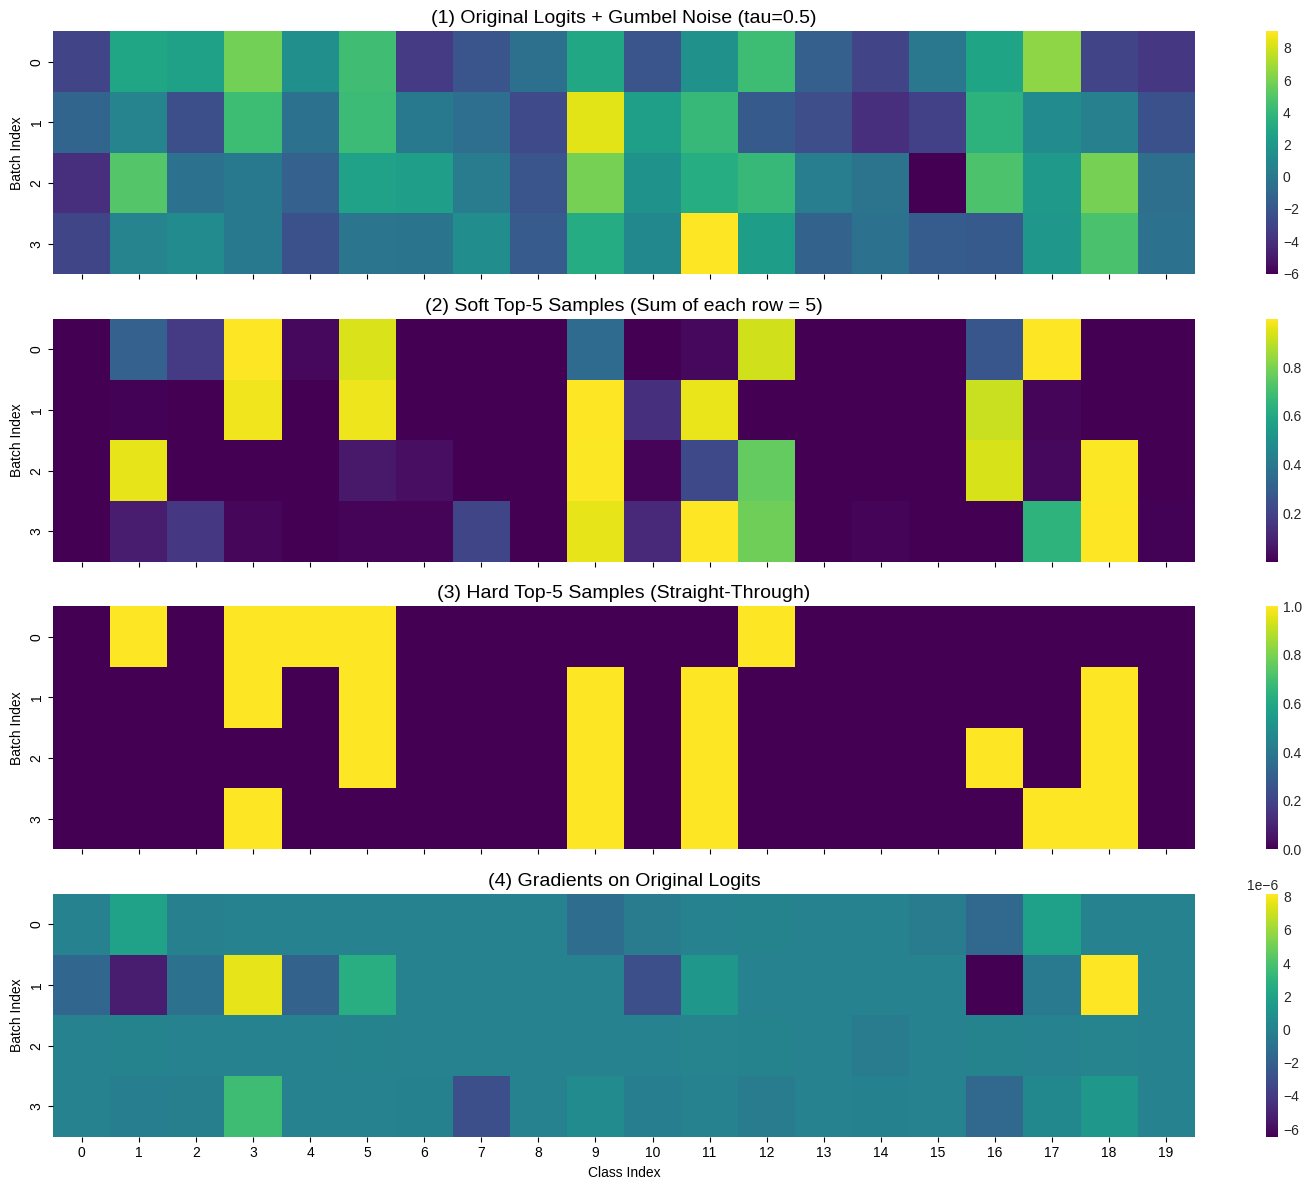

Test Parameters: batch_size=4, num_classes=20, k=5, temperature=0.5

[INFO] Original Logits (첫 번째 샘플):
[-3.84  3.8   0.77  5.85  1.62  5.3  -1.68 -2.89 -0.58  1.91 -1.21 -0.47
  4.97 -1.65 -3.67 -1.27  0.5   3.36 -2.21 -4.4 ]

[INFO] Gumbel-perturbed Logits (첫 번째 샘플):
[-2.98  2.86  2.56  5.84  1.46  4.4  -3.44 -2.07 -0.52  2.92 -2.09  1.51
  4.27 -1.52 -2.99  0.02  2.79  6.45 -3.03 -3.65]

[INFO] Soft Top-5 Samples (첫 번째 샘플):
[0.   0.31 0.17 1.   0.02 0.94 0.   0.   0.   0.34 0.   0.02 0.93 0.
 0.   0.   0.27 1.   0.   0.  ]
-> Sum of a soft sample row: 5.0000

[INFO] Hard Top-5 Samples (첫 번째 샘플):
[0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
-> Sum of a hard sample row: 5

[INFO] Gradients on Logits (첫 번째 샘플):
[ 0.  0. -0.  0.  0.  0. -0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0.  0.
  0.  0.]

[INFO] Total number of non-zero gradients: 18 / 80
-> 모든 로짓에 경사도가 흐르는 것을 확인할 수 있습니다.


In [1]:
# ===================================================================
#                      Jupyter Notebook Cell
# ===================================================================

# 필요한 라이브러리 임포트
import torch
from torch.autograd import Function
import numpy as np
import numpy.random as npr
import scipy.special as spec
import matplotlib.pyplot as plt
import seaborn as sns

# --- 제공된 코드 부분 ---

EPS = torch.finfo(torch.float32).tiny
INF = np.finfo(np.float32).max

def softtopk_forward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, 0, 0] = 0
    messages[:, 0, 1] = logits[:, 0]
    for i in range(1, n):
        for j in range(k + 1):
            logp_dont_use = messages[:, i - 1, j]
            logp_use = (
                messages[:, i - 1, j - 1] + logits[:, i] if j > 0 else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_backward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, n - 1, k] = 0
    for i in range(n - 2, -1, -1):
        for j in range(k + 1):
            logp_dont_use = messages[:, i + 1, j]
            logp_use = (
                messages[:, i + 1, j + 1] + logits[:, i + 1] if j < k else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_np(logits, k):
    batchsize = logits.shape[0]
    f = softtopk_forward_np(logits, k)
    b = softtopk_backward_np(logits, k)
    initial_f = -INF * np.ones((batchsize, 1, k + 1))
    initial_f[:, :, 0] = 0
    ff = np.concatenate([initial_f, f[:, :-1, :]], axis=1)
    lse0 = spec.logsumexp(ff + b, axis=2)
    lse1 = spec.logsumexp(ff[:, :, :-1] + b[:, :, 1:], axis=2) + logits
    lse_total = np.logaddexp(lse0, lse1)
    # 분모가 0이 되는 것을 방지하기 위해 아주 작은 값(EPS)을 더해줍니다.
    return np.exp(lse1 - lse_total + EPS)

class SoftTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits, k, eps):
        ctx.save_for_backward(logits)
        ctx.k = k
        ctx.eps = eps
        dtype = logits.dtype
        device = logits.device
        mu_np = softtopk_np(logits.cpu().detach().numpy(), k)
        mu = torch.from_numpy(mu_np).type(dtype).to(device)
        return mu

    @staticmethod
    def backward(ctx, grad_output):
        logits, = ctx.saved_tensors
        k = ctx.k
        eps= ctx.eps
        dtype = grad_output.dtype
        device = grad_output.device
        logits_np = logits.cpu().detach().numpy()
        grad_output_np = grad_output.cpu().detach().numpy()
        n1 = softtopk_np(logits_np + eps * grad_output_np, k)
        n2 = softtopk_np(logits_np - eps * grad_output_np, k)
        grad_np = (n1 - n2) / (2 * eps)
        grad = torch.from_numpy(grad_np).type(dtype).to(device)
        return grad, None, None

def sample_topk_from_logits(logits, k, tau=1.0, hard=False, 
                            hard_with_grad=False,
                            relaxation="exp_family_entropy", 
                            eps=1e-2):
    # 이 함수는 그래프 구조를 가정하므로, 일반적인 테스트를 위해 단순화합니다.
    # 원래 함수는 복잡한 reshape 과정이 있으므로 핵심 로직만 가져와서 테스트합니다.
    
    # Gumbel 노이즈 추가
    uniforms = torch.empty_like(logits).float().uniform_().clamp_(EPS, 1 - EPS)
    gumbels = uniforms.log().neg().log().neg()
    gumbels = gumbels.cuda() if logits.is_cuda else gumbels
    weights_for_topk = gumbels + logits
    weights_for_soft = (gumbels + logits) / tau

    # Hard (이산) 샘플링
    if hard or hard_with_grad:
        _, topk_indices = torch.topk(weights_for_topk, k, dim=-1)
        hard_X = torch.zeros_like(logits).scatter(-1, topk_indices, 1.0)
        if not hard_with_grad:
            return hard_X, weights_for_topk # Soft 계산 없이 반환

    # Soft (연속) 샘플링
    if relaxation == "exp_family_entropy":
        soft_X = SoftTopK.apply(weights_for_soft, k, eps)
    else:
        raise ValueError("Invalid relaxation for topk.")

    # Straight-Through Estimator 적용
    if hard_with_grad:
        return (hard_X - soft_X).detach() + soft_X, weights_for_topk
    else:
        return soft_X, weights_for_topk

# --- 테스트용 파라미터 설정 ---
batch_size = 4
num_classes = 20
k = 5
temperature = 0.5
np.random.seed(42)
torch.manual_seed(42)

# --- 1. 임의의 로짓 생성 ---
# 일부 로짓은 높고 일부는 낮게 만들어 시각적으로 구분이 쉽게 함
logits = torch.cat([
    torch.randn(batch_size, num_classes // 2) * 2 + 2,  # 높은 값들
    torch.randn(batch_size, num_classes // 2) * 2 - 2   # 낮은 값들
], dim=1)
# 섞어주기
logits = logits[:, torch.randperm(num_classes)]
logits.requires_grad = True

# --- 2. Soft & Hard Top-K 샘플링 수행 ---
# Soft 샘플
soft_samples, gumbel_logits = sample_topk_from_logits(
    logits, k, tau=temperature, hard=False, relaxation="exp_family_entropy"
)

# Hard 샘플 (with gradient)
hard_samples_with_grad, _ = sample_topk_from_logits(
    logits, k, tau=temperature, hard_with_grad=True, relaxation="exp_family_entropy"
)

# --- 3. 역전파를 통한 경사도 계산 ---
# hard 샘플의 합을 손실로 가정하고 역전파
loss = hard_samples_with_grad.sum()
loss.backward()
gradients = logits.grad

# --- 4. 결과 시각화 ---
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 데이터 변환 (시각화를 위해 numpy로)
logits_np = logits.detach().numpy()
soft_samples_np = soft_samples.detach().numpy()
hard_samples_np = hard_samples_with_grad.detach().numpy()
gradients_np = gradients.detach().numpy()
gumbel_logits_np = gumbel_logits.detach().numpy()

titles = [
    f"(1) Original Logits + Gumbel Noise (tau={temperature})",
    f"(2) Soft Top-{k} Samples (Sum of each row = {k})",
    f"(3) Hard Top-{k} Samples (Straight-Through)",
    f"(4) Gradients on Original Logits"
]
data_to_plot = [gumbel_logits_np, soft_samples_np, hard_samples_np, gradients_np]

for i, (ax, data, title) in enumerate(zip(axes, data_to_plot, titles)):
    sns.heatmap(data, ax=ax, cmap="viridis", annot=False, cbar=True)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Batch Index")

axes[-1].set_xlabel("Class Index")
plt.tight_layout()
plt.show()

# --- 5. 수치적 결과 출력 ---
print("="*50)
print(f"Test Parameters: batch_size={batch_size}, num_classes={num_classes}, k={k}, temperature={temperature}")
print("="*50)

print("\n[INFO] Original Logits (첫 번째 샘플):")
print(np.round(logits_np[0], 2))

print("\n[INFO] Gumbel-perturbed Logits (첫 번째 샘플):")
print(np.round(gumbel_logits_np[0], 2))

print(f"\n[INFO] Soft Top-{k} Samples (첫 번째 샘플):")
print(np.round(soft_samples_np[0], 2))
print(f"-> Sum of a soft sample row: {soft_samples_np[0].sum():.4f}") # 합은 k가 되어야 함

print(f"\n[INFO] Hard Top-{k} Samples (첫 번째 샘플):")
print(np.round(hard_samples_np[0], 2))
print(f"-> Sum of a hard sample row: {hard_samples_np[0].sum():.0f}")

print("\n[INFO] Gradients on Logits (첫 번째 샘플):")
print(np.round(gradients_np[0], 2))

# 경사도가 0이 아닌 값의 개수 확인
num_non_zero_grads = (np.abs(gradients_np) > 1e-6).sum()
print(f"\n[INFO] Total number of non-zero gradients: {num_non_zero_grads} / {gradients_np.size}")
print("-> 모든 로짓에 경사도가 흐르는 것을 확인할 수 있습니다.")

In [2]:
gradients

tensor([[ 3.6985e-11,  1.9336e-06, -1.5310e-07,  8.9644e-09,  1.5356e-08,
          1.1352e-08, -3.0141e-09, -2.1828e-09, -1.9288e-08, -1.3001e-06,
         -3.6078e-07, -1.9775e-08,  5.8101e-08,  8.2837e-12, -1.6810e-09,
         -4.0675e-07, -1.5692e-06,  1.8086e-06,  3.7697e-12,  2.1199e-13],
        [-1.7107e-06, -5.3097e-06, -1.0052e-06,  7.5969e-06, -1.8573e-06,
          2.6925e-06, -8.3612e-09,  1.0774e-09,  1.4282e-10,  6.1080e-09,
         -2.9346e-06,  1.3432e-06, -1.8041e-08,  1.6957e-10,  1.1015e-11,
          1.5816e-10, -6.4639e-06, -4.9262e-07,  8.1576e-06,  2.6375e-09],
        [ 2.8706e-15,  8.0081e-08, -2.3332e-09, -2.3854e-08,  3.1537e-13,
          8.2119e-08, -4.6839e-08, -2.5520e-09, -1.8845e-08,  1.1513e-09,
         -4.0772e-09,  1.1241e-07,  9.7426e-08, -8.9024e-09, -4.2446e-07,
          6.9344e-17,  5.8285e-08,  4.2159e-09,  1.2278e-07, -2.6603e-08],
        [ 6.9125e-13, -2.8135e-07, -1.9350e-07,  3.6413e-06,  6.7928e-11,
         -3.6207e-09, -1.0268e-07, 

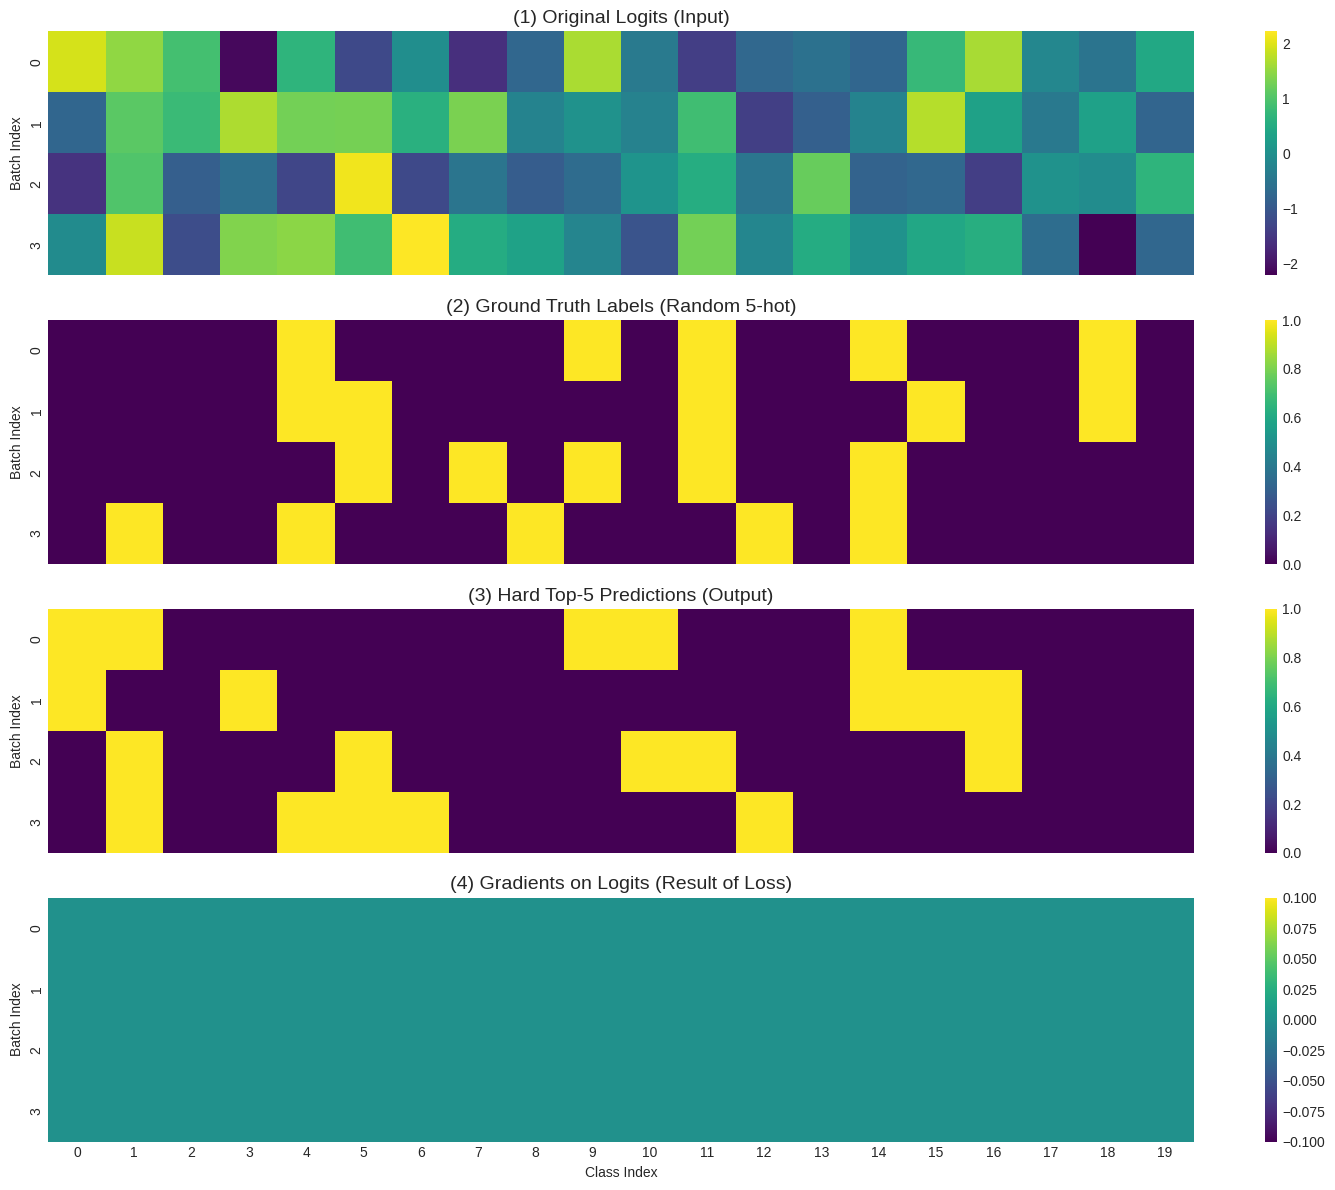

Test Parameters: batch_size=4, num_classes=20, k=5, temperature=0.5
Calculated Loss (MSE): 0.3000

[INFO] Ground Truth (첫 번째 샘플):
[0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0]

[INFO] Hard Top-5 Prediction (첫 번째 샘플):
[1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0]

[INFO] Gradients on Logits (첫 번째 샘플):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

[INFO] Total number of non-zero gradients: 0 / 80
-> 모든 로짓에 경사도가 흐르는 것을 다시 한번 확인할 수 있습니다.


In [3]:
# ===================================================================
#           수정된 Jupyter Notebook 셀 (일반화 및 직관적 Loss)
# ===================================================================

# 필요한 라이브러리 임포트
import torch
from torch.autograd import Function
import numpy as np
import numpy.random as npr
import scipy.special as spec
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

# --- 제공된 코드 부분 (수정 없음) ---
# ... (이전 셀의 SoftTopK 및 관련 numpy 함수 코드를 여기에 그대로 붙여넣습니다) ...
EPS = torch.finfo(torch.float32).tiny
INF = np.finfo(np.float32).max

def softtopk_forward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, 0, 0] = 0
    messages[:, 0, 1] = logits[:, 0]
    for i in range(1, n):
        for j in range(k + 1):
            logp_dont_use = messages[:, i - 1, j]
            logp_use = (
                messages[:, i - 1, j - 1] + logits[:, i] if j > 0 else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_backward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, n - 1, k] = 0
    for i in range(n - 2, -1, -1):
        for j in range(k + 1):
            logp_dont_use = messages[:, i + 1, j]
            logp_use = (
                messages[:, i + 1, j + 1] + logits[:, i + 1] if j < k else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_np(logits, k):
    batchsize = logits.shape[0]
    f = softtopk_forward_np(logits, k)
    b = softtopk_backward_np(logits, k)
    initial_f = -INF * np.ones((batchsize, 1, k + 1))
    initial_f[:, :, 0] = 0
    ff = np.concatenate([initial_f, f[:, :-1, :]], axis=1)
    lse0 = spec.logsumexp(ff + b, axis=2)
    lse1 = spec.logsumexp(ff[:, :, :-1] + b[:, :, 1:], axis=2) + logits
    lse_total = np.logaddexp(lse0, lse1)
    return np.exp(lse1 - lse_total + EPS)

class SoftTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits, k, eps):
        ctx.save_for_backward(logits)
        ctx.k = k
        ctx.eps = eps
        dtype = logits.dtype
        device = logits.device
        mu_np = softtopk_np(logits.cpu().detach().numpy(), k)
        mu = torch.from_numpy(mu_np).type(dtype).to(device)
        return mu

    @staticmethod
    def backward(ctx, grad_output):
        logits, = ctx.saved_tensors
        k = ctx.k
        eps= ctx.eps
        dtype = grad_output.dtype
        device = grad_output.device
        logits_np = logits.cpu().detach().numpy()
        grad_output_np = grad_output.cpu().detach().numpy()
        n1 = softtopk_np(logits_np + eps * grad_output_np, k)
        n2 = softtopk_np(logits_np - eps * grad_output_np, k)
        grad_np = (n1 - n2) / (2 * eps)
        grad = torch.from_numpy(grad_np).type(dtype).to(device)
        return grad, None, None

# --- 일반화된 Top-K 샘플링 함수 ---
def sample_gumbel_topk(logits, k, tau=1.0, hard=False, eps=1e-10):
    """
    일반적인 (B, N) 형태의 로짓을 처리하는 Gumbel Top-K 샘플링 함수.
    
    Args:
        logits (torch.Tensor): (batch_size, num_classes) 형태의 로짓.
        k (int): 선택할 상위 항목의 수.
        tau (float): 온도 파라미터.
        hard (bool): True이면 Straight-Through Estimator를 사용한 hard 샘플링.
        eps (float): Gumbel 노이즈 및 SoftTopK 계산 시 수치 안정을 위한 작은 값.
    
    Returns:
        torch.Tensor: 샘플링된 결과 (soft 또는 hard-with-grad).
    """
    # Gumbel 노이즈 추가
    gumbels = -torch.empty_like(logits, memory_format=torch.contiguous_format).exponential_().log()
    gumbel_logits = (logits + gumbels) / tau
    
    # Soft (연속) 샘플 계산
    soft_samples = SoftTopK.apply(gumbel_logits, k, eps)
    
    if hard:
        # Straight-Through Estimator
        # Forward pass에서는 이산적인 k-hot 벡터를 사용
        _, topk_indices = torch.topk(gumbel_logits, k, dim=-1)
        hard_samples = torch.zeros_like(logits).scatter_(-1, topk_indices, 1.0)
        # Backward pass에서는 soft_samples의 경사도를 사용
        return (hard_samples - soft_samples).detach() + soft_samples
    else:
        return soft_samples

# --- 테스트용 파라미터 설정 ---
batch_size = 4
num_classes = 20
k = 5
temperature = 0.5
np.random.seed(42)
torch.manual_seed(42)

# --- 1. 임의의 로짓 생성 ---
logits = torch.randn(batch_size, num_classes)
logits.requires_grad = True

# --- 2. 가상의 Ground Truth Label 생성 (Random k-hot vector) ---
gt_indices = torch.stack([torch.randperm(num_classes)[:k] for _ in range(batch_size)])
ground_truth_labels = torch.zeros_like(logits).scatter_(-1, gt_indices, 1.0)

# --- 3. Hard Top-K 예측 및 Loss 계산 ---
# 모델의 예측값
predictions = sample_gumbel_topk(logits, k, tau=temperature, hard=True)

# MSE Loss 계산
loss = F.mse_loss(predictions, ground_truth_labels)

# --- 4. 역전파를 통한 경사도 계산 ---
loss.backward()
gradients = logits.grad

# --- 5. 결과 시각화 ---
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 데이터 변환
logits_np = logits.detach().numpy()
labels_np = ground_truth_labels.detach().numpy()
preds_np = predictions.detach().numpy()
gradients_np = gradients.detach().numpy()

titles = [
    f"(1) Original Logits (Input)",
    f"(2) Ground Truth Labels (Random {k}-hot)",
    f"(3) Hard Top-{k} Predictions (Output)",
    f"(4) Gradients on Logits (Result of Loss)"
]
data_to_plot = [logits_np, labels_np, preds_np, gradients_np]

for i, (ax, data, title) in enumerate(zip(axes, data_to_plot, titles)):
    sns.heatmap(data, ax=ax, cmap="viridis", annot=False, cbar=True)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Batch Index")

axes[-1].set_xlabel("Class Index")
plt.tight_layout()
plt.show()

# --- 6. 수치적 결과 출력 ---
print("="*50)
print(f"Test Parameters: batch_size={batch_size}, num_classes={num_classes}, k={k}, temperature={temperature}")
print(f"Calculated Loss (MSE): {loss.item():.4f}")
print("="*50)

print("\n[INFO] Ground Truth (첫 번째 샘플):")
print(labels_np[0].astype(int))

print(f"\n[INFO] Hard Top-{k} Prediction (첫 번째 샘플):")
print(preds_np[0].astype(int))

print("\n[INFO] Gradients on Logits (첫 번째 샘플):")
print(np.round(gradients_np[0], 3))

# 경사도가 0이 아닌 값의 개수 확인
num_non_zero_grads = (np.abs(gradients_np) > 1e-6).sum()
print(f"\n[INFO] Total number of non-zero gradients: {num_non_zero_grads} / {gradients_np.size}")
print("-> 모든 로짓에 경사도가 흐르는 것을 다시 한번 확인할 수 있습니다.")

--- 설정 ---
Batch Size: 5, Num Items: 12, K: 4
Target Labels (k-hot vectors):
tensor([[0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
        [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]], dtype=torch.int32)
--------------------------------------------------

--- 1. Soft Sampling (미분 가능한 확률 벡터) ---
Soft Samples (sum should be k=4):
tensor([[0.9290, 0.3320, 0.9200, 0.0140, 0.3220, 0.0130, 0.0200, 0.0710, 0.0790,
         0.9170, 0.0390, 0.3440],
        [0.0100, 0.0340, 0.0520, 0.5620, 0.9470, 0.8250, 0.0110, 0.2370, 0.0170,
         0.2630, 0.0620, 0.9810],
        [0.1570, 0.7750, 0.4220, 0.6620, 0.0380, 0.8680, 0.1360, 0.3760, 0.0040,
         0.1010, 0.0740, 0.3870],
        [0.9210, 0.1880, 0.1210, 0.0360, 0.0300, 0.8490, 0.0480, 0.0390, 0.1830,
         0.0700, 0.8400, 0.6760],
        [0.1320, 0.5140, 0.9330, 0.3690, 0.3320, 0.6110, 0.2740, 0.1360, 0.1010,
      

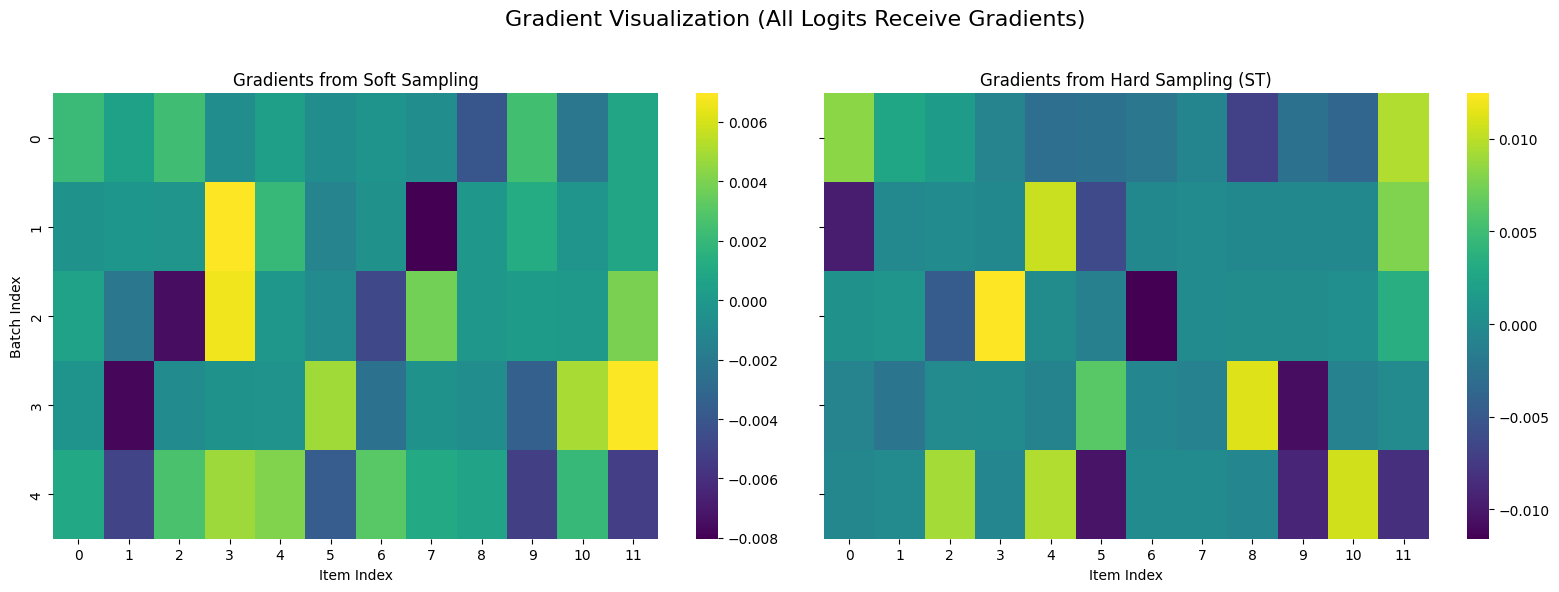

In [9]:
import torch
from torch.autograd import Function
import torch.nn.functional as F
import numpy as np
import scipy.special as spec
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. 제공해주신 엄밀한 SoftTopK 구현 (수정 없음)
# =============================================================================
EPS = torch.finfo(torch.float32).tiny
INF = np.finfo(np.float32).max

def softtopk_forward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, 0, 0] = 0
    messages[:, 0, 1] = logits[:, 0]
    for i in range(1, n):
        for j in range(k + 1):
            logp_dont_use = messages[:, i - 1, j]
            logp_use = (
                messages[:, i - 1, j - 1] + logits[:, i] if j > 0 else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_backward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, n - 1, k] = 0
    for i in range(n - 2, -1, -1):
        for j in range(k + 1):
            logp_dont_use = messages[:, i + 1, j]
            logp_use = (
                messages[:, i + 1, j + 1] + logits[:, i + 1] if j < k else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_np(logits, k):
    batchsize = logits.shape[0]
    f = softtopk_forward_np(logits, k)
    b = softtopk_backward_np(logits, k)
    initial_f = -INF * np.ones((batchsize, 1, k + 1))
    initial_f[:, :, 0] = 0
    ff = np.concatenate([initial_f, f[:, :-1, :]], axis=1)
    lse0 = spec.logsumexp(ff + b, axis=2)
    lse1 = spec.logsumexp(ff[:, :, :-1] + b[:, :, 1:], axis=2) + logits
    return np.exp(lse1 - np.logaddexp(lse0, lse1))

class SoftTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits, k, eps):
        ctx.save_for_backward(logits)
        ctx.k = k
        ctx.eps = eps
        dtype = logits.dtype
        device = logits.device
        mu_np = softtopk_np(logits.cpu().detach().numpy(), k)
        mu = torch.from_numpy(mu_np).type(dtype).to(device)
        return mu

    @staticmethod
    def backward(ctx, grad_output):
        logits, = ctx.saved_tensors
        k = ctx.k
        eps= ctx.eps
        dtype = grad_output.dtype
        device = grad_output.device
        logits_np = logits.cpu().detach().numpy()
        grad_output_np = grad_output.cpu().detach().numpy()
        n1 = softtopk_np(logits_np + eps * grad_output_np, k)
        n2 = softtopk_np(logits_np - eps * grad_output_np, k)
        grad_np = (n1 - n2) / (2 * eps)
        grad = torch.from_numpy(grad_np).type(dtype).to(device)
        return grad, None, None

# =============================================================================
# 2. 일반적인 (B, N) 입력을 위한 래퍼 함수
# =============================================================================
def sample_topk_generic(logits, k, tau=1.0, hard=False, eps=1e-2):
    """
    일반적인 (B, N) 로짓 입력에 대해 k개의 아이템을 샘플링합니다.
    hard=True일 경우 Straight-Through Estimator를 사용합니다.
    """
    # Gumbel-Max 트릭 적용
    uniforms = torch.empty_like(logits).float().uniform_().clamp_(EPS, 1 - EPS)
    gumbels = -torch.log(-torch.log(uniforms))
    noisy_logits = logits + gumbels
    
    # SST를 통해 미분 가능한 soft 샘플 계산
    soft_sample = SoftTopK.apply(noisy_logits / tau, k, eps)

    if hard:
        # 이산적인 hard 샘플 생성
        _, topk_indices = torch.topk(noisy_logits, k, dim=-1)
        hard_sample = torch.zeros_like(logits).scatter_(-1, topk_indices, 1.0)
        # Straight-Through Estimator 결합
        return (hard_sample - soft_sample).detach() + soft_sample
    else:
        return soft_sample

# =============================================================================
# 3. 테스트 및 시각화
# =============================================================================

# --- 하이퍼파라미터 설정 ---
batch_size = 5
num_items = 12
k = 4
temperature = 0.8
torch.manual_seed(42) # 재현성을 위한 시드 고정

# --- 임의의 데이터 생성 ---
# 모델의 출력을 시뮬레이션하는 로짓
logits = torch.randn(batch_size, num_items, requires_grad=True)

# 학습 목표가 되는 k-hot 벡터 레이블
# 각 행에서 k개의 1을 무작위로 가지도록 생성
label_indices = torch.stack([torch.randperm(num_items)[:k] for _ in range(batch_size)])
labels = torch.zeros_like(logits).scatter_(-1, label_indices, 1.0)

print(f"--- 설정 ---")
print(f"Batch Size: {batch_size}, Num Items: {num_items}, K: {k}")
print(f"Target Labels (k-hot vectors):\n{labels.int()}")
print("-" * 50)


# --- Soft 샘플링 테스트 ---
print("\n--- 1. Soft Sampling (미분 가능한 확률 벡터) ---")
soft_samples = sample_topk_generic(logits, k, tau=temperature, hard=False)

# 결과 출력
print(f"Soft Samples (sum should be k={k}):")
# 소수점 셋째 자리까지 반올림하여 출력
print(torch.round(soft_samples * 1000) / 1000)
print(f"Sum of soft samples per row:\n{soft_samples.sum(-1)}")

# 경사도 확인
loss_soft = F.mse_loss(soft_samples, labels)
loss_soft.backward()
grad_soft = logits.grad.clone()
logits.grad.zero_() # 다음 테스트를 위해 경사도 초기화

print(f"\nMSE Loss (Soft): {loss_soft.item():.4f}")
print("Gradients from Soft Samples:")
print(torch.round(grad_soft * 1000) / 1000)
print(f"모든 로짓에 0이 아닌 gradient가 존재하는가? -> {torch.all(grad_soft != 0)}")
print("-" * 50)


# --- Hard 샘플링 (with Straight-Through) 테스트 ---
print("\n--- 2. Hard Sampling (with Straight-Through Estimator) ---")
hard_samples = sample_topk_generic(logits, k, tau=temperature, hard=True)

# 결과 출력
print("Hard Samples (k-hot vectors):")
print(hard_samples.int())
print(f"Sum of hard samples per row:\n{hard_samples.sum(-1)}")

# 경사도 확인
loss_hard = F.mse_loss(hard_samples, labels)
loss_hard.backward()
grad_hard = logits.grad.clone()
logits.grad.zero_()

print(f"\nMSE Loss (Hard): {loss_hard.item():.4f}")
print("Gradients from Hard Samples (via ST Estimator):")
print(torch.round(grad_hard * 1000) / 1000)
print(f"모든 로짓에 0이 아닌 gradient가 존재하는가? -> {torch.all(grad_hard != 0)}")
print("-" * 50)


# --- 경사도 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Gradient Visualization (All Logits Receive Gradients)", fontsize=16)

sns.heatmap(grad_soft.numpy(), ax=axes[0], cmap="viridis", annot=False)
axes[0].set_title("Gradients from Soft Sampling")
axes[0].set_xlabel("Item Index")
axes[0].set_ylabel("Batch Index")

sns.heatmap(grad_hard.numpy(), ax=axes[1], cmap="viridis", annot=False)
axes[1].set_title("Gradients from Hard Sampling (ST)")
axes[1].set_xlabel("Item Index")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
diffsort.diffsort.get_sorting_network?

Signature: diffsort.diffsort.get_sorting_network(type, n, device)
Docstring: <no docstring>
File:      ~/miniconda3/envs/hoyso_ml/lib/python3.11/site-packages/diffsort/networks.py
Type:      function

In [6]:
!pip install diffsort

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


--- 설정 ---
Batch Size: 5, Num Items: 12, K: 4
--------------------------------------------------


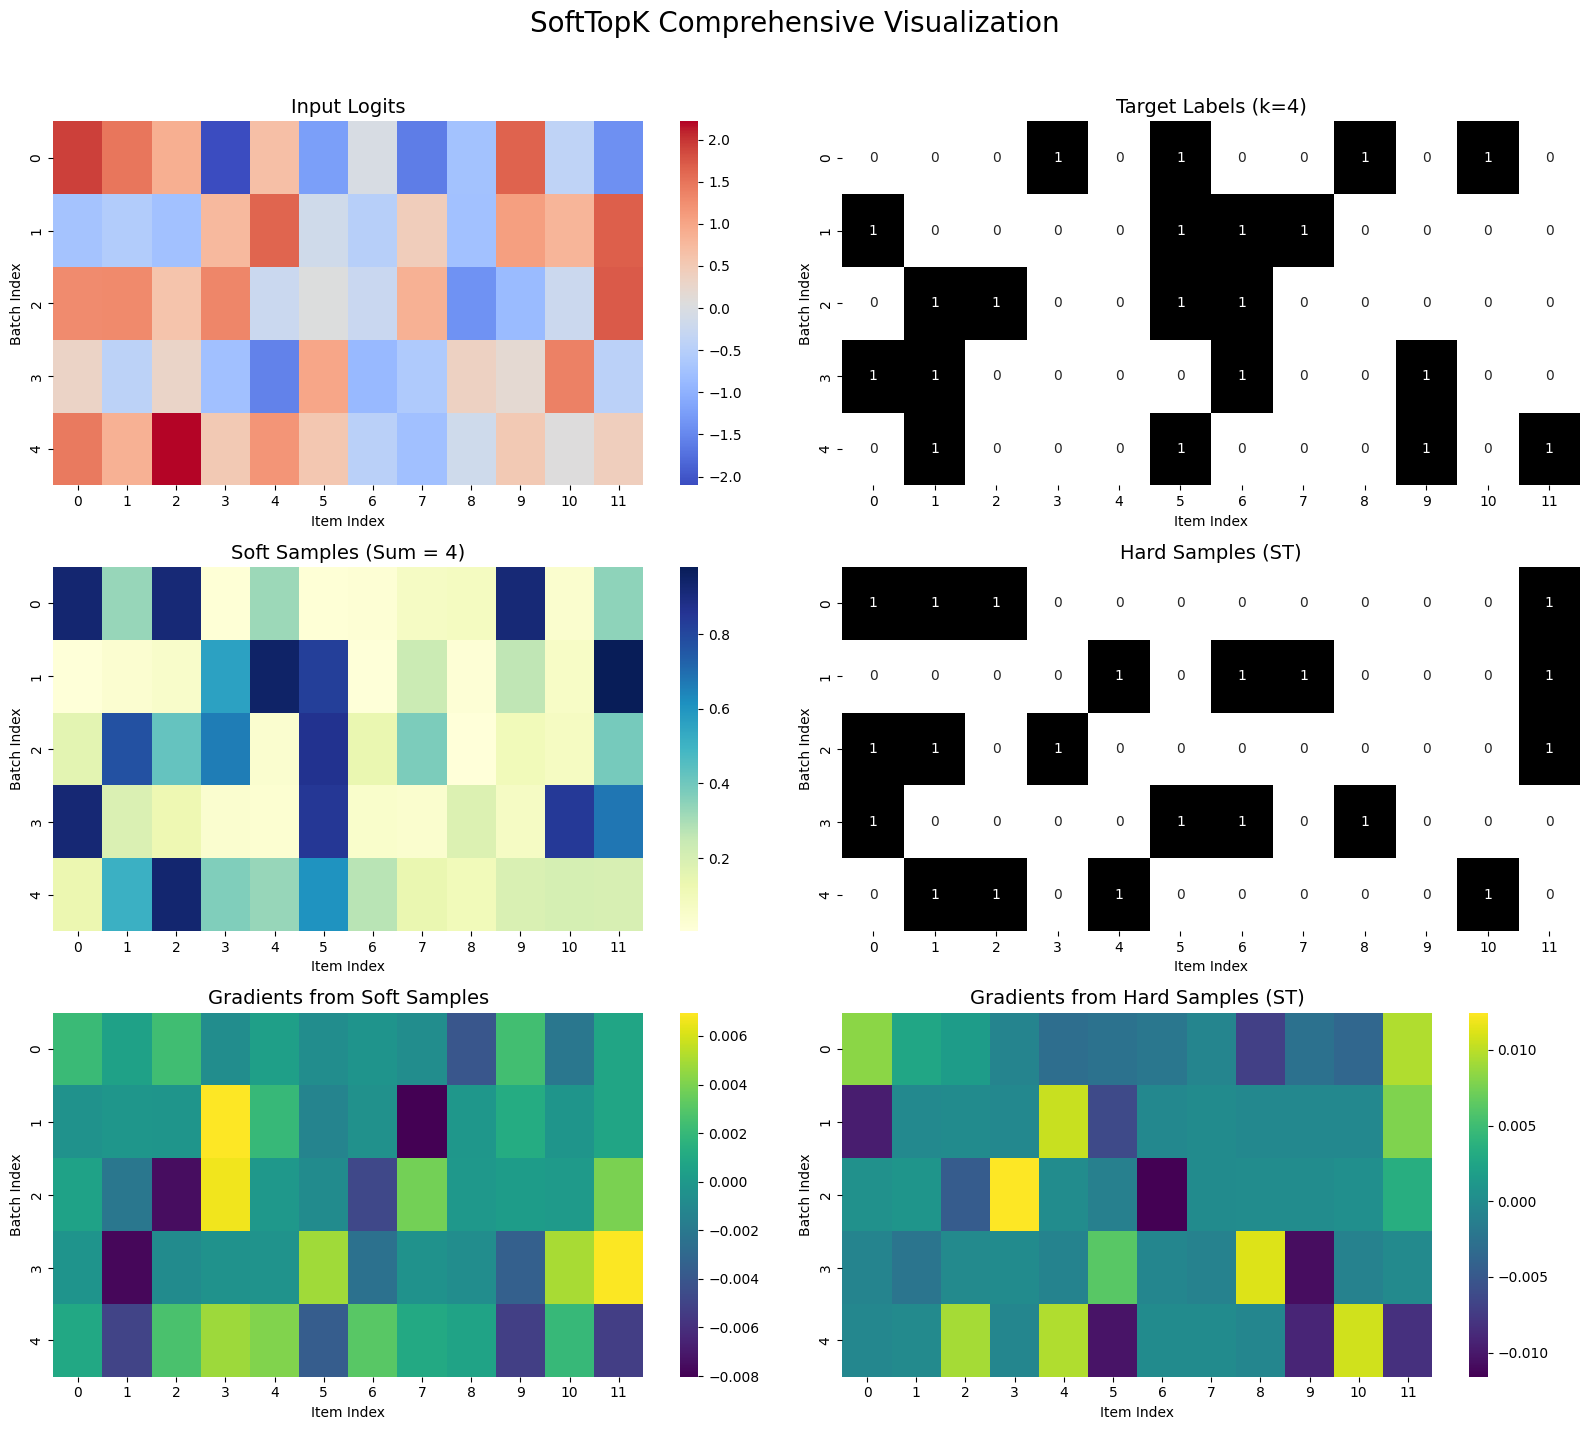


--- Numerical Results ---
MSE Loss (Soft): 0.3447
MSE Loss (Hard): 0.4667
모든 로짓에 0이 아닌 gradient가 흐르는가 (Soft)? -> True
모든 로짓에 0이 아닌 gradient가 흐르는가 (Hard)? -> True


In [10]:
# =============================================================================
# 3. 테스트 및 시각화 (업그레이드 버전)
# =============================================================================

# --- 하이퍼파라미터 설정 ---
batch_size = 5
num_items = 12
k = 4
temperature = 0.8
torch.manual_seed(42) # 재현성을 위한 시드 고정

# --- 임의의 데이터 생성 ---
# 모델의 출력을 시뮬레이션하는 로짓
logits = torch.randn(batch_size, num_items, requires_grad=True)

# 학습 목표가 되는 k-hot 벡터 레이블
# 각 행에서 k개의 1을 무작위로 가지도록 생성
label_indices = torch.stack([torch.randperm(num_items)[:k] for _ in range(batch_size)])
labels = torch.zeros_like(logits).scatter_(-1, label_indices, 1.0)

print(f"--- 설정 ---")
print(f"Batch Size: {batch_size}, Num Items: {num_items}, K: {k}")
print("-" * 50)


# --- Soft 샘플링 테스트 ---
soft_samples = sample_topk_generic(logits, k, tau=temperature, hard=False)
loss_soft = F.mse_loss(soft_samples, labels)
loss_soft.backward()
grad_soft = logits.grad.clone()
logits.grad.zero_() # 다음 테스트를 위해 경사도 초기화


# --- Hard 샘플링 (with Straight-Through) 테스트 ---
hard_samples = sample_topk_generic(logits, k, tau=temperature, hard=True)
loss_hard = F.mse_loss(hard_samples, labels)
loss_hard.backward()
grad_hard = logits.grad.clone()
logits.grad.zero_()


# --- 시각화 ---
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("SoftTopK Comprehensive Visualization", fontsize=20, y=0.95)

# 1. 입력 로짓 (Input Logits)
sns.heatmap(logits.detach().numpy(), ax=axes[0, 0], cmap="coolwarm", cbar=True)
axes[0, 0].set_title("Input Logits", fontsize=14)
axes[0, 0].set_ylabel("Batch Index")
axes[0, 0].set_xlabel("Item Index")

# 2. 목표 레이블 (Target Labels)
sns.heatmap(labels.numpy(), ax=axes[0, 1], cmap="Greys", cbar=False, annot=True, fmt=".0f")
axes[0, 1].set_title(f"Target Labels (k={k})", fontsize=14)
axes[0, 1].set_ylabel("Batch Index")
axes[0, 1].set_xlabel("Item Index")

# 3. Soft 샘플 (Soft Samples)
sns.heatmap(soft_samples.detach().numpy(), ax=axes[1, 0], cmap="YlGnBu", cbar=True, annot=False)
axes[1, 0].set_title(f"Soft Samples (Sum = {k})", fontsize=14)
axes[1, 0].set_ylabel("Batch Index")
axes[1, 0].set_xlabel("Item Index")

# 4. Hard 샘플 (Hard Samples)
sns.heatmap(hard_samples.detach().numpy(), ax=axes[1, 1], cmap="Greys", cbar=False, annot=True, fmt=".0f")
axes[1, 1].set_title("Hard Samples (ST)", fontsize=14)
axes[1, 1].set_ylabel("Batch Index")
axes[1, 1].set_xlabel("Item Index")

# 5. Soft 샘플의 경사도 (Gradients from Soft Samples)
sns.heatmap(grad_soft.numpy(), ax=axes[2, 0], cmap="viridis", cbar=True)
axes[2, 0].set_title("Gradients from Soft Samples", fontsize=14)
axes[2, 0].set_ylabel("Batch Index")
axes[2, 0].set_xlabel("Item Index")

# 6. Hard 샘플의 경사도 (Gradients from Hard Samples)
sns.heatmap(grad_hard.numpy(), ax=axes[2, 1], cmap="viridis", cbar=True)
axes[2, 1].set_title("Gradients from Hard Samples (ST)", fontsize=14)
axes[2, 1].set_ylabel("Batch Index")
axes[2, 1].set_xlabel("Item Index")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- 수치 결과 출력 ---
print("\n--- Numerical Results ---")
print(f"MSE Loss (Soft): {loss_soft.item():.4f}")
print(f"MSE Loss (Hard): {loss_hard.item():.4f}")
print(f"모든 로짓에 0이 아닌 gradient가 흐르는가 (Soft)? -> {torch.all(grad_soft != 0)}")
print(f"모든 로짓에 0이 아닌 gradient가 흐르는가 (Hard)? -> {torch.all(grad_hard != 0)}")

Epoch [20000/20000]
Soft Loss: 0.0059 | Hard Loss: 0.0500


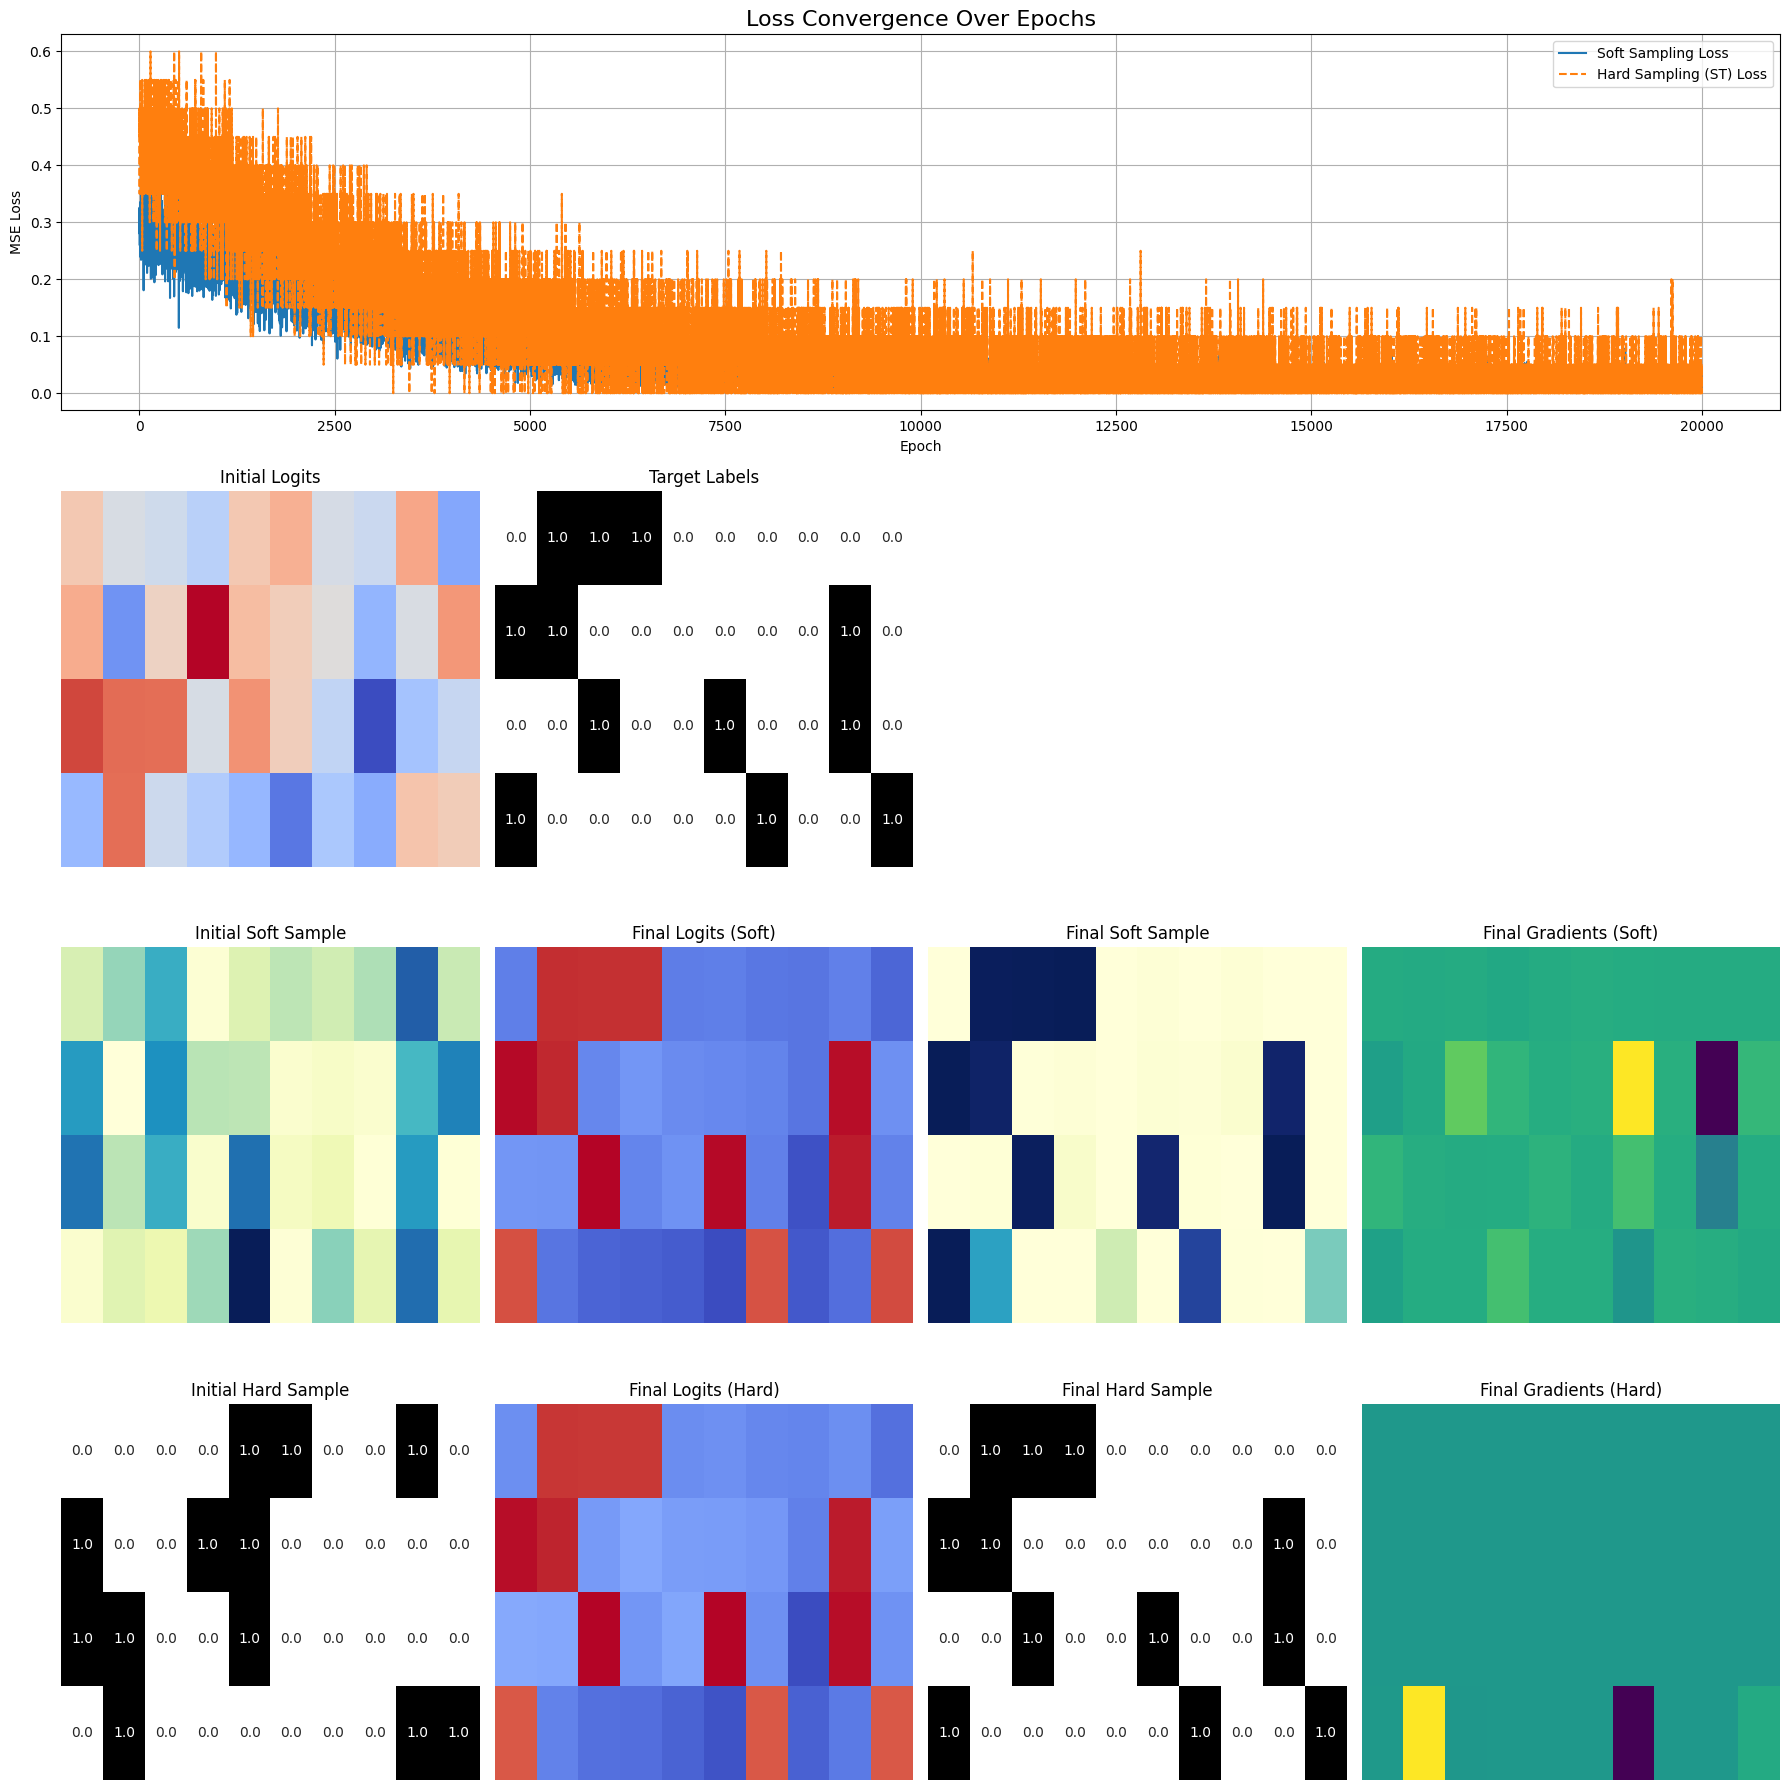

In [12]:
import torch
from torch.autograd import Function
import torch.nn.functional as F
import numpy as np
import scipy.special as spec
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# =============================================================================
# 1. & 2. SoftTopK 구현 및 래퍼 함수 (이전과 동일)
# =============================================================================
EPS = torch.finfo(torch.float32).tiny
INF = np.finfo(np.float32).max

def softtopk_forward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, 0, 0] = 0
    messages[:, 0, 1] = logits[:, 0]
    for i in range(1, n):
        for j in range(k + 1):
            logp_dont_use = messages[:, i - 1, j]
            logp_use = (
                messages[:, i - 1, j - 1] + logits[:, i] if j > 0 else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_backward_np(logits, k):
    batchsize, n = logits.shape
    messages = -INF * np.ones((batchsize, n, k + 1))
    messages[:, n - 1, k] = 0
    for i in range(n - 2, -1, -1):
        for j in range(k + 1):
            logp_dont_use = messages[:, i + 1, j]
            logp_use = (
                messages[:, i + 1, j + 1] + logits[:, i + 1] if j < k else -INF)
            message = np.logaddexp(logp_dont_use, logp_use)
            messages[:, i, j] = message
    return messages

def softtopk_np(logits, k):
    batchsize = logits.shape[0]
    f = softtopk_forward_np(logits, k)
    b = softtopk_backward_np(logits, k)
    initial_f = -INF * np.ones((batchsize, 1, k + 1))
    initial_f[:, :, 0] = 0
    ff = np.concatenate([initial_f, f[:, :-1, :]], axis=1)
    lse0 = spec.logsumexp(ff + b, axis=2)
    lse1 = spec.logsumexp(ff[:, :, :-1] + b[:, :, 1:], axis=2) + logits
    return np.exp(lse1 - np.logaddexp(lse0, lse1))

class SoftTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits, k, eps):
        ctx.save_for_backward(logits)
        ctx.k = k
        ctx.eps = eps
        dtype = logits.dtype
        device = logits.device
        mu_np = softtopk_np(logits.cpu().detach().numpy(), k)
        mu = torch.from_numpy(mu_np).type(dtype).to(device)
        return mu

    @staticmethod
    def backward(ctx, grad_output):
        logits, = ctx.saved_tensors
        k = ctx.k
        eps= ctx.eps
        dtype = grad_output.dtype
        device = grad_output.device
        logits_np = logits.cpu().detach().numpy()
        grad_output_np = grad_output.cpu().detach().numpy()
        n1 = softtopk_np(logits_np + eps * grad_output_np, k)
        n2 = softtopk_np(logits_np - eps * grad_output_np, k)
        grad_np = (n1 - n2) / (2 * eps)
        grad = torch.from_numpy(grad_np).type(dtype).to(device)
        return grad, None, None

def sample_topk_generic(logits, k, tau=1.0, hard=False, eps=1e-2):
    uniforms = torch.empty_like(logits).float().uniform_().clamp_(EPS, 1 - EPS)
    gumbels = -torch.log(-torch.log(uniforms))
    noisy_logits = logits + gumbels
    soft_sample = SoftTopK.apply(noisy_logits / tau, k, eps)
    if hard:
        _, topk_indices = torch.topk(noisy_logits, k, dim=-1)
        hard_sample = torch.zeros_like(logits).scatter_(-1, topk_indices, 1.0)
        return (hard_sample - soft_sample).detach() + soft_sample
    else:
        return soft_sample

# =============================================================================
# 3. 로짓 최적화 및 수렴 과정 시각화
# =============================================================================

# --- 하이퍼파라미터 설정 ---
batch_size = 4
num_items = 10
k = 3
temperature = 1.0
learning_rate = 0.1
epochs = 20000
torch.manual_seed(123)

# --- 데이터 생성 ---
# 초기 로짓 (Soft와 Hard용으로 두 개를 복제)
initial_logits = torch.randn(batch_size, num_items)
logits_soft = initial_logits.clone().requires_grad_(True)
logits_hard = initial_logits.clone().requires_grad_(True)

# 목표 레이블
label_indices = torch.stack([torch.randperm(num_items)[:k] for _ in range(batch_size)])
labels = torch.zeros_like(initial_logits).scatter_(-1, label_indices, 1.0)

# --- 최적화 준비 ---
optimizer_soft = torch.optim.SGD([logits_soft], lr=learning_rate)
optimizer_hard = torch.optim.SGD([logits_hard], lr=learning_rate)
loss_history_soft = []
loss_history_hard = []

# --- 학습 루프 ---
print("--- Optimizing Logits using SoftTopK Gradients ---")
for epoch in range(epochs):
    # Soft 샘플링 최적화
    optimizer_soft.zero_grad()
    samples_soft = sample_topk_generic(logits_soft, k, tau=temperature, hard=False)
    loss_s = F.mse_loss(samples_soft, labels)
    loss_s.backward()
    optimizer_soft.step()
    loss_history_soft.append(loss_s.item())
    
    # Hard 샘플링 최적화
    optimizer_hard.zero_grad()
    samples_hard = sample_topk_generic(logits_hard, k, tau=temperature, hard=True)
    loss_h = F.mse_loss(samples_hard, labels)
    loss_h.backward()
    optimizer_hard.step()
    loss_history_hard.append(loss_h.item())
    
    # 진행 상황 출력
    if (epoch + 1) % 10 == 0:
        clear_output(wait=True)
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Soft Loss: {loss_s.item():.4f} | Hard Loss: {loss_h.item():.4f}")

# --- 최종 결과 및 시각화 ---
final_samples_soft = sample_topk_generic(logits_soft, k, tau=temperature, hard=False)
final_samples_hard = sample_topk_generic(logits_hard, k, tau=temperature, hard=True)

fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(4, 4)

# 손실 그래프
ax_loss = fig.add_subplot(gs[0, :])
ax_loss.plot(loss_history_soft, label='Soft Sampling Loss')
ax_loss.plot(loss_history_hard, label='Hard Sampling (ST) Loss', linestyle='--')
ax_loss.set_title("Loss Convergence Over Epochs", fontsize=16)
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("MSE Loss")
ax_loss.legend()
ax_loss.grid(True)

# 시각화 함수
def create_heatmap(ax, data, title, cmap="viridis", annot=False, fmt=".1f"):
    sns.heatmap(data.detach().numpy(), ax=ax, cmap=cmap, annot=annot, fmt=fmt, cbar=False)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# 초기 상태
ax1 = fig.add_subplot(gs[1, 0])
create_heatmap(ax1, initial_logits, "Initial Logits", cmap="coolwarm")
ax2 = fig.add_subplot(gs[1, 1])
create_heatmap(ax2, labels, "Target Labels", cmap="Greys", annot=True)
ax3 = fig.add_subplot(gs[2, 0])
create_heatmap(ax3, sample_topk_generic(initial_logits, k, hard=False), "Initial Soft Sample", cmap="YlGnBu")
ax4 = fig.add_subplot(gs[3, 0])
create_heatmap(ax4, sample_topk_generic(initial_logits, k, hard=True), "Initial Hard Sample", cmap="Greys", annot=True)

# Soft 샘플링 최종 결과
ax5 = fig.add_subplot(gs[2, 1])
create_heatmap(ax5, logits_soft, "Final Logits (Soft)", cmap="coolwarm")
ax6 = fig.add_subplot(gs[2, 2])
create_heatmap(ax6, final_samples_soft, "Final Soft Sample", cmap="YlGnBu")
ax7 = fig.add_subplot(gs[2, 3])
loss_s_final = F.mse_loss(final_samples_soft, labels)
final_samples_soft.backward(torch.ones_like(final_samples_soft)) # gradient 계산
create_heatmap(ax7, logits_soft.grad, "Final Gradients (Soft)", cmap="viridis")

# Hard 샘플링 최종 결과
ax8 = fig.add_subplot(gs[3, 1])
create_heatmap(ax8, logits_hard, "Final Logits (Hard)", cmap="coolwarm")
ax9 = fig.add_subplot(gs[3, 2])
create_heatmap(ax9, final_samples_hard, "Final Hard Sample", cmap="Greys", annot=True)
ax10 = fig.add_subplot(gs[3, 3])
loss_h_final = F.mse_loss(final_samples_hard, labels)
final_samples_hard.backward(torch.ones_like(final_samples_hard)) # gradient 계산
create_heatmap(ax10, logits_hard.grad, "Final Gradients (Hard)", cmap="viridis")


plt.tight_layout()
plt.show()

In [2]:
import torch
t = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)
x = torch.tensor([[0, 0], [1, 0]], requires_grad=True)
loss = torch.gather(t, 1, x)
loss.mean().backward()
x.grad

RuntimeError: Only Tensors of floating point and complex dtype can require gradients

In [6]:
merge_map

tensor([[0, 1, 2, 3, 0, 0, 0, 3, 0, 1, 2, 3, 0, 1, 0, 3, 0, 0, 2, 0],
        [0, 1, 2, 3, 0, 0, 0, 3, 0, 1, 0, 3, 0, 0, 0, 3, 0, 1, 2, 3]])

In [18]:
merge_map

tensor([[0, 1, 2, 3, 0, 5, 0, 1, 0, 1, 2, 5, 0, 0, 0, 3, 0, 0, 0, 2],
        [0, 1, 2, 0, 0, 5, 0, 1, 0, 1, 0, 0, 0, 2, 3, 3, 0, 1, 0, 3]])

In [21]:
import torch
import torch.nn as nn
from typing import Tuple, Callable, List

class TrueCausalToMe(nn.Module):
    def __init__(self, r: float = 0.5, kernel_size: int = 2, num_iterations: int = 1, use_padding: bool = False, offset_cycling: bool = False):
        super().__init__()
        self.r, self.kernel_size, self.num_iterations, self.use_padding, self.offset_cycling = r, kernel_size, num_iterations, use_padding, offset_cycling

    # _find_roots and _create_unmerge_fn are correct and remain the same.
    @staticmethod
    @torch.no_grad()
    def _find_roots(merge_map: torch.Tensor) -> torch.Tensor:
        B, N = merge_map.shape
        final_dest = torch.arange(N, device=merge_map.device).unsqueeze(0).expand(B, -1)
        for _ in range(N):
            gathered_offsets = torch.gather(merge_map, 1, final_dest)
            next_dest = final_dest - gathered_offsets
            if (next_dest == final_dest).all(): break
            final_dest = next_dest
        return final_dest

    def merge(self, metric: torch.Tensor) -> Tuple[torch.Tensor, Callable, torch.Tensor]:
        B, N, C = metric.shape
        device = metric.device

        if self.r == 0:
            return metric, lambda x: x, torch.zeros(B, N, dtype=torch.long, device=device)

        x = metric.clone()
        current_indices = torch.arange(N, device=device).unsqueeze(0).expand(B, -1)
        history: List[Tuple[torch.Tensor, torch.Tensor]] = []
        
        total_tokens_to_reduce = int(self.r * N)
        merges_per_iter = total_tokens_to_reduce // self.num_iterations
        
        for i in range(self.num_iterations):
            current_N = x.shape[1]
            if current_N < self.kernel_size: break
            offset = (i % self.kernel_size) if self.offset_cycling else 0
            if offset >= current_N: continue

            valid_len = current_N - offset
            num_sub_groups = valid_len // self.kernel_size
            if num_sub_groups == 0: continue
            
            end_idx = offset + num_sub_groups * self.kernel_size
            sub_groups = x[:, offset:end_idx].view(B, num_sub_groups, self.kernel_size, C)
            sim = nn.functional.cosine_similarity(sub_groups[:, :, 0:1, :], sub_groups[:, :, 1:, :], dim=-1)
            
            sim_flat = sim.view(B, -1)
            k = min(merges_per_iter, sim_flat.shape[1])
            if k == 0: continue
            
            _, top_indices_flat = torch.topk(sim_flat, k, dim=1)
            
            group_indices = top_indices_flat // (self.kernel_size - 1)
            src_offset_in_group = top_indices_flat % (self.kernel_size - 1)
            
            dst_indices = (group_indices * self.kernel_size) + offset
            src_indices = dst_indices + src_offset_in_group + 1
            
            # --- Local iter_map and history ---
            iter_map = torch.zeros(B, current_N, dtype=torch.long, device=device)
            map_values = src_offset_in_group + 1
            iter_map.scatter_(1, src_indices, map_values)
            history.append((iter_map, current_indices))
            
            # --- Merge Step ---
            dst_toks = torch.gather(x, 1, dst_indices.unsqueeze(-1).expand(-1, -1, C))
            src_toks = torch.gather(x, 1, src_indices.unsqueeze(-1).expand(-1, -1, C))
            x.scatter_(1, dst_indices.unsqueeze(-1).expand(-1, -1, C), (dst_toks + src_toks) / 2.0)
            
            mask_to_keep = torch.ones(B, current_N, dtype=torch.bool, device=device)
            mask_to_keep.scatter_(1, src_indices, False)
            
            x = x[mask_to_keep].view(B, -1, C)
            current_indices = current_indices[mask_to_keep].view(B, -1)

        merged_tokens = x

        # --- THE CORRECT COMPOSITION LOGIC ---
        final_merge_map = torch.zeros(B, N, dtype=torch.long, device=device)
        for iter_map, root_indices in reversed(history):
            # 1. Get the existing offsets for the roots of this iteration
            existing_offsets = torch.gather(final_merge_map, 1, root_indices)
            
            # 2. Add the local iter_map to them
            # This implements: final_map[roots] += iter_map
            updated_offsets = existing_offsets + iter_map
            
            # 3. Scatter the new, combined offsets back to the final map
            final_merge_map.scatter_(1, root_indices, updated_offsets)
            
        final_destinations = self._find_roots(final_merge_map)
        unmerge_fn = self._create_unmerge_fn(final_destinations)

        return merged_tokens, unmerge_fn, final_merge_map

    @staticmethod
    def _create_unmerge_fn(final_destinations: torch.Tensor) -> Callable:
        B, N_original = final_destinations.shape
        is_root = (final_destinations == torch.arange(N_original, device=final_destinations.device))
        
        def unmerge_fn(y: torch.Tensor) -> torch.Tensor:
            B_y, _, C_y = y.shape
            unmerged = torch.zeros(B_y, N_original, C_y, device=y.device, dtype=y.dtype)
            for b in range(B_y):
                roots_b = torch.where(is_root[b])[0]
                map_root_to_y_idx = torch.full((N_original,), -1, dtype=torch.long, device=y.device)
                map_root_to_y_idx[roots_b] = torch.arange(len(roots_b), device=y.device)
                indices_in_y = map_root_to_y_idx[final_destinations[b]]
                unmerged[b] = y[b, indices_in_y]
            return unmerged
        return unmerge_fn
    
    def forward(self, metric: torch.Tensor) -> Tuple[torch.Tensor, Callable, torch.Tensor]:
        return self.merge(metric)

# --- Test Code ---
if __name__ == '__main__':
    B, N, C = 2, 20, 8
    R = 0.5
    KERNEL_SIZE = 4
    NUM_ITERATIONS = 2
    
    torch.manual_seed(0)
    input_tensor = torch.randn(B, N, C)
    # Make some tokens similar to test merging
    input_tensor[:, 1] = input_tensor[:, 0] * 0.99
    input_tensor[:, 8] = input_tensor[:, 4] * 0.99
    input_tensor[:, 9] = input_tensor[:, 8] * 0.99 # Chain: 9->8, 8->4
    input_tensor[:, 15] = input_tensor[:, 12] * 0.99

    print("--- Configuration ---")
    print(f"Batch={B}, N={N}, C={C}")
    print(f"r={R}, kernel_size={KERNEL_SIZE}, num_iterations={NUM_ITERATIONS}, use_padding=False")
    print("-" * 20)

    merger = TrueCausalToMe(r=R, kernel_size=KERNEL_SIZE, num_iterations=NUM_ITERATIONS, use_padding=True)
    merged_tokens, unmerge_fn, merge_map = merger.merge(input_tensor)

    print("--- Outputs ---")
    print(f"Original shape: {input_tensor.shape}")
    print(f"Merged tokens shape: {merged_tokens.shape}")
    
    print("\n--- Final Merge Map (Batch 0) ---")
    print("idx\tmerge_offset (0 ~ K-1)")
    for i, offset in enumerate(merge_map[0]):
        if offset > 0:
            print(f"{i}\t(offset={offset.item()})")
        else:
            print(f"{i}\t(is a root)")
    
    assert torch.all(merge_map < KERNEL_SIZE), f"Merge map values must be < {KERNEL_SIZE}"
    print("\nMerge map value range test passed.")

    final_roots = merger._find_roots(merge_map)[0]
    print("\n--- Final Roots (Batch 0) ---")
    print(final_roots.tolist())
    
    print("\n--- A simple case: r=0.5, kernel_size=2, iters=1 ---")
    merger_simple = CorrectCausalToMe(r=0.5, kernel_size=2, num_iterations=1)
    simple_input = torch.arange(10, dtype=torch.float32).view(1, 10, 1)
    simple_merged, _, simple_map = merger_simple(simple_input)
    print(f"Input: {simple_input.squeeze().numpy().tolist()}")
    print(f"Merge Map: {simple_map.squeeze().numpy().tolist()}")
    print(f"Merged Tokens: {torch.round(simple_merged.squeeze(), decimals=2).numpy().tolist()}")
    
    # Expected output for simple case:
    # Merge map should be [0, 1, 0, 1, 0, 1, 0, 1, 0, 1] because all pairs are merged
    # Merged tokens should be [0.5, 2.5, 4.5, 6.5, 8.5]
    expected_map = torch.tensor([[0,1,0,1,0,1,0,1,0,1]])
    assert torch.equal(simple_map, expected_map)
    print("Simple case test passed.")

--- Configuration ---
Batch=2, N=20, C=8
r=0.5, kernel_size=4, num_iterations=2, use_padding=False
--------------------
--- Outputs ---
Original shape: torch.Size([2, 20, 8])
Merged tokens shape: torch.Size([2, 10, 8])

--- Final Merge Map (Batch 0) ---
idx	merge_offset (0 ~ K-1)
0	(is a root)
1	(offset=1)
2	(is a root)
3	(offset=3)
4	(offset=2)
5	(offset=3)
6	(is a root)
7	(offset=1)
8	(is a root)
9	(offset=1)
10	(offset=2)
11	(offset=3)
12	(is a root)
13	(offset=1)
14	(is a root)
15	(offset=3)
16	(is a root)
17	(is a root)
18	(is a root)
19	(is a root)

Merge map value range test passed.

--- Final Roots (Batch 0) ---
[0, 0, 2, 0, 2, 2, 6, 6, 8, 8, 8, 8, 12, 12, 14, 12, 16, 17, 18, 19]

--- A simple case: r=0.5, kernel_size=2, iters=1 ---
Input: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
Merge Map: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Merged Tokens: [0.5, 2.5, 4.5, 6.5, 8.5]
Simple case test passed.


In [ ]:
# causal_tome_1d.py
"""Causal ToMe (Token Merging) for 1‑D token sequences
======================================================

This is a **from‑scratch** re‑implementation of *Token Merging* (ToMe) that satisfies
all constraints laid out in the user specification for *1‑D* sequences:

* **Causal** merging (information only flows *left*).
* **Sliding‑window** partitioning (``kernel_size == stride`` only for now).
* Supports arbitrary *iterations* and *offset cycling*.
* Optional *padding* for trailing tokens.
* Returns a **merge‑map** of shape ``(B, N)`` whose values lie in
  ``{0, …, kernel_size‑1}`` and match the exact semantic definition provided.
* Uses purely *PyTorch* tensor ops (no Python loops over token length) and keeps
  the autograd graph **intact** (selection under ``torch.no_grad()``, merging with
  gradients).

The top‑level entry‑point is :pyfunc:`causal_tome_1d`, which returns:

1. The *merged* token tensor ``x_reduced``.
2. A callable ``unmerge`` that maps any tensor of shape ``(B, N_reduced, …)``
   back to ``(B, N, …)`` by duplicating along the merge‑map.
3. The final *merge‑map* ``merge_map`` itself.

The implementation is fully *batch‑parallel* (no loops over ``B``) and contains
no hidden state.  All randomness (if desired) must be supplied via a
``torch.Generator`` passed to :pyfunc:`causal_tome_1d`.
"""
from __future__ import annotations

from typing import Callable, List, Tuple
import math

import torch
import torch.nn.functional as F

# -----------------------------------------------------------------------------
# Helper utilities
# -----------------------------------------------------------------------------

def _norm(x: torch.Tensor, eps: float = 1e‑12) -> torch.Tensor:
    """L2‑normalise last dimension."""
    return x / (x.square().sum(dim=-1, keepdim=True) + eps).sqrt()


def _partition_indices(
    N: int,
    kernel_size: int,
    stride: int,
    offset: int,
    device: torch.device,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Return *(anchor_idx, src_idx)* for the current offset.

    * ``anchor_idx`` – shape ``(G,)`` – indices of the first token of each window.
    * ``src_idx``    – shape ``(G, kernel_size‑1)`` – indices of causal *src*
      candidates **within** each window; invalid (> N‑1) positions are left as
      ``‑1`` and *must* be masked by the caller.
    """
    assert kernel_size == stride, "Overlapping windows (k > s) not supported yet."

    # Number of complete windows that *fit* once the offset is applied
    G = max((N - offset + stride - 1) // stride, 0)

    anchor_idx = offset + torch.arange(G, device=device) * stride  # (G,)

    if G == 0:
        # Degenerate – nothing fits (e.g. offset > N‑1).  Return empties.
        return anchor_idx, torch.empty(0, kernel_size - 1, device=device, dtype=torch.long)

    rel_src = torch.arange(1, kernel_size, device=device)  # (k‑1,)
    src_idx = anchor_idx.unsqueeze(1) + rel_src  # (G, k‑1)

    # Mark indices that spill past ``N`` with ‑1 so they can be masked later.
    src_idx[src_idx >= N] = -1
    return anchor_idx, src_idx


# -----------------------------------------------------------------------------
# Merge‑map utilities (distance propagation across iterations)
# -----------------------------------------------------------------------------

def _propagate_merge_maps(
    iter_maps: List[torch.Tensor],
) -> torch.Tensor:
    """Combine *iteration‑level* merge maps into the **final** ``(B, N)`` map.

    Each ``iter_maps[i]`` is already on the correct device and has dtype
    ``torch.long``.  The algorithm follows the specification exactly.
    """
    # Work on a copy to avoid in‑place mutation issues when autograd is used.
    maps: List[torch.Tensor] = [m.clone() for m in iter_maps]

    # Iterate *backwards*.
    for i in range(len(maps) - 1, 0, -1):
        prev, cur = maps[i - 1], maps[i]  # NOTE: shapes differ across iters.
        B, N_prev = prev.shape

        # Find zero positions in *prev* (these are the kept dst tokens that form
        # the *current* sequence).
        kept_mask = prev == 0  # (B, N_prev)  – boolean.
        kept_pos  = torch.nonzero(kept_mask, as_tuple=False)  # (M, 2) – [b, idx]

        # The *distance* array is computed **per‑batch**.
        # Build an expanded tensor so we can index directly without Python loops.
        batch_ids, idxs = kept_pos[:, 0], kept_pos[:, 1]
        # For each batch, compute distances between consecutive kept positions.
        # We do this via groupby on the batch dimension.
        distances = torch.zeros_like(idxs)
        for b in range(B):
            sel = batch_ids == b
            if not torch.any(sel):
                continue
            pos = idxs[sel]
            # pos is already sorted (from nonzero scan order).
            diff = torch.diff(pos, prepend=pos[:1])  # prepend first for same len
            distances[sel] = diff - 1  # diff‑1, with first element becoming 0.

        # distances is length M (same order as kept_pos).
        # Build a (B, len(cur)) view so broadcasting works.
        distance_full = torch.full_like(cur, 0)  # (B, len(cur))
        # We need to scatter *distances* (which correspond to kept_pos order)
        # into *distance_full* along the second dimension.
        distance_full[kept_mask] = distances

        # Update *prev* at kept positions.
        add_term = cur + (cur > 0).long() * distance_full  # eq. + 1{>0} * dist
        prev[kept_mask] += add_term.view(-1)

        maps[i - 1] = prev  # in‑place mutate OK.

    return maps[0]  # final map for original sequence


# -----------------------------------------------------------------------------
# Main entry‑point
# -----------------------------------------------------------------------------

def causal_tome_1d(
    x: torch.Tensor,  # (B, N, C)
    r: float,
    *,
    kernel_size: int = 2,
    stride: int = 2,
    num_iterations: int = 1,
    offset_cycling: bool = False,
    use_padding: bool = True,
    generator: torch.Generator | None = None,
) -> Tuple[torch.Tensor, Callable[[torch.Tensor], torch.Tensor], torch.Tensor]:
    """Causal ToMe for 1‑D sequences.

    Parameters
    ----------
    x : ``(B, N, C)``
        Input token tensor.
    r : float
        *Overall* reduction ratio – e.g. 0.5 removes 50 % of tokens **in total**.
    kernel_size, stride : int
        Window parameters (currently **must** satisfy ``kernel_size == stride``).
    num_iterations : int
        How many iterative reduction steps to perform.
    offset_cycling : bool
        If *True*, offsets cycle through ``0 … kernel_size‑1`` each iteration.
    use_padding : bool
        If *True*, the last incomplete window is **padded** (masked from merging).
    generator : ``torch.Generator`` | None
        Optional RNG (for future extensions).  Currently unused because selection
        is purely *deterministic* (Top‑K by similarity).
    """
    assert 0.0 < r < 1.0, "`r` must be in (0, 1)."
    assert kernel_size == stride, "Only the non‑overlapping case is supported."
    assert num_iterations >= 1, "Need at least one iteration."

    B, N_orig, C = x.shape
    device       = x.device

    # How many tokens *overall* must disappear.
    total_merges = int(math.floor(r * N_orig))
    if total_merges == 0:
        # Degenerate – nothing to merge.
        def unmerge(y: torch.Tensor) -> torch.Tensor:  # identity
            return y
        merge_map = torch.zeros(B, N_orig, dtype=torch.long, device=device)
        return x, unmerge, merge_map

    # Pre‑compute how many merges to commit *each* iteration.
    base = total_merges // num_iterations
    extra = total_merges % num_iterations  # first `extra` iters get +1 merge
    merges_per_iter = [base + (1 if i < extra else 0) for i in range(num_iterations)]

    # Track *sizes* so we can compute weighted averages.
    sizes = torch.ones(B, N_orig, 1, device=device, dtype=x.dtype)

    # Keep lists so we can propagate maps later.
    iter_maps: List[torch.Tensor] = []

    # Current (shrinking) tensors
    tokens = x
    token_sizes = sizes
    cur_N = N_orig

    # ------------------------------------------------------------------
    # Main iterative reduction loop
    # ------------------------------------------------------------------
    for itr in range(num_iterations):
        merges_target = merges_per_iter[itr]
        if merges_target == 0 or cur_N <= 1:
            # Nothing to merge this round – just record a zero map.
            iter_maps.append(torch.zeros(B, cur_N, dtype=torch.long, device=device))
            continue

        offset = (itr % kernel_size) if offset_cycling else 0
        anchor_idx, src_idx = _partition_indices(
            cur_N, kernel_size, stride, offset, device
        )  # (G,), (G,k‑1)
        G = anchor_idx.shape[0]
        if G == 0 or src_idx.numel() == 0:
            # Not enough tokens to fit even a single window.
            iter_maps.append(torch.zeros(B, cur_N, dtype=torch.long, device=device))
            continue

        # Build similarity scores under no_grad.
        with torch.no_grad():
            # Gather anchor (dst) and src candidate embeddings.
            anchor = tokens.index_select(1, anchor_idx)         # (B,G,C)
            src    = tokens.index_select(1, src_idx.view(-1))   # (B,G*(k‑1),C)
            src    = src.view(B, G, kernel_size - 1, C)         # (B,G,k‑1,C)

            # Cosine sim *only* along allowed causal direction (anchor <- src).
            sim = (_norm(anchor).unsqueeze(2) * _norm(src)).sum(dim=-1)  # (B,G,k‑1)

            # Mask invalid (padded) src positions.
            invalid = src_idx == -1
            if invalid.any():
                sim = sim.masked_fill(invalid.unsqueeze(0), float('-inf'))

            # Flatten to (B, G*(k‑1)) for Top‑K.
            sim_flat = sim.view(B, -1)
            k_candidate = sim_flat.shape[1]
            merges_now  = min(merges_target, k_candidate)
            if merges_now == 0:
                iter_maps.append(torch.zeros(B, cur_N, dtype=torch.long, device=device))
                continue

            # Indices of Top‑K per‑batch.
            topk_val, topk_idx = torch.topk(sim_flat, k=merges_now, dim=1, largest=True, sorted=False)
            # Convert flattened idx → (group, pos)
            group_idx  = topk_idx // (kernel_size - 1)          # (B,K)
            rel_offset = (topk_idx % (kernel_size - 1)) + 1     # (B,K) ∈ [1,k‑1]
            dst_idx    = anchor_idx.index_select(0, group_idx.view(-1))  # (B*K,) broadcast later
            src_idx_sel = dst_idx + rel_offset.view(-1)

            # Because anchor_idx is independent of batch, above select is fine.
            dst_idx     = dst_idx.view(B, merges_now)
            src_idx_sel = src_idx_sel.view(B, merges_now)

        # ------------------------------------------------------------------
        # Build merge‑map *for this iteration* (before shape shrink)
        # ------------------------------------------------------------------
        merge_map_t = torch.zeros(B, cur_N, dtype=torch.long, device=device)
        # token_idx - dst_idx gives distance ∈ [1, k‑1]
        distance_vals = (src_idx_sel - dst_idx).long()
        # Scatter into merge_map_t.
        merge_map_t.scatter_(dim=1, index=src_idx_sel, src=distance_vals)

        # Record *before* shrinking.
        iter_maps.append(merge_map_t)

        # ------------------------------------------------------------------
        # Actually merge (with gradients)
        # ------------------------------------------------------------------
        # Prepare gather masks.
        keep_mask = torch.ones(B, cur_N, dtype=torch.bool, device=device)
        keep_mask.scatter_(1, src_idx_sel, False)  # merged src will be dropped

        # For weighted average we work with *weight = token * size*.
        weight = tokens * token_sizes  # (B,cur_N,C)

        # Scatter‑add source weights & sizes into dst positions.
        expanded_dst = dst_idx_sel = dst_idx  # alias rename for clarity

        # weights: accumulate first
        weight = weight.index_add(1, dst_idx_sel.view(-1), weight.gather(1, src_idx_sel.unsqueeze(-1).expand(-1, -1, C)).view(-1, C))
        # sizes: accumulate
        token_sizes = token_sizes.index_add(1, dst_idx_sel.view(-1), token_sizes.gather(1, src_idx_sel.unsqueeze(-1)))

        # Compute new tokens = weight / size
        tokens = weight / token_sizes

        # Finally drop merged src tokens.
        tokens      = tokens[keep_mask].view(B, -1, C)
        token_sizes = token_sizes[keep_mask].view(B, -1, 1)
        cur_N       = tokens.shape[1]

    # ----------------------------------------------------------------------
    # Combine iteration‑level maps into the final merge‑map (B,N_orig)
    # ----------------------------------------------------------------------
    merge_map = _propagate_merge_maps(iter_maps)

    # ----------------------------------------------------------------------
    # Build *unmerge* callable for downstream use.
    # ----------------------------------------------------------------------
    kept_mask_final = merge_map == 0  # (B,N_orig)
    # Position (rank) of each kept token in the reduced sequence.
    rank = torch.cumsum(kept_mask_final.int(), dim=1) - 1  # (B,N_orig)

    def unmerge(y: torch.Tensor) -> torch.Tensor:
        """Broadcast `y` (B, N_reduced, …) back to (B, N_orig, …)."""
        B_, N_reduced = y.shape[:2]
        assert B_ == B, "Batch size mismatch in unmerge()."
        # Gather along *reduced* dimension using the *rank* mapping.
        # For tokens that were merged, their *anchor* rank is at
        # ``rank[b, anchor_idx]`` where ``anchor_idx = i - merge_map``.
        idx = (torch.arange(N_orig, device=device)[None, :] - merge_map).long()  # anchor absolute idx
        anchor_rank = rank.gather(1, idx)  # (B,N_orig)
        out = y.gather(1, anchor_rank.unsqueeze(-1).expand(-1, -1, y.shape[-1]))
        return out

    return tokens, unmerge, merge_map


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Callable, Union, Literal, List, Optional

class GeneralizedConvolutionalTokenMerger(nn.Module):
    """
    Implements a generalized, iterative token merging algorithm for 1D sequences,
    conceptualized as a 1D convolutional operation, based on the provided
    technical specification.

    This module takes a tensor of token metrics, progressively merges them based on
    similarity within sliding windows (kernels), and produces a final merged tensor
    along with a `merge_map` that describes the entire operation.
    """

    def __init__(self,
                 causal: bool = False,
                 kernel_size: int = 2,
                 strides: int = 1,
                 num_iterations: int = 1,
                 dst_offset: Union[int, Literal['random']] = 0,
                 offset: Union[int, Literal['cycle', 'random']] = 0,
                 use_padding: bool = False,
                 gumbel_tau: float = 1.0):
        """
        Initializes the token merging algorithm with its hyperparameters.

        Args:
            causal (bool): If True, merging is strictly unidirectional (i <- j, i < j).
                           This forces dst_offset to be 0.
            kernel_size (int): The size of the sliding window for merging.
            strides (int): The step size for the sliding window.
            num_iterations (int): The total number of progressive merging steps.
            dst_offset (int or 'random'): Defines the destination token's index within a kernel.
                                           Ignored and set to 0 if causal is True.
            offset (int, 'cycle', or 'random'): The initial offset for the sliding window in each iteration.
            use_padding (bool): If True, pad the sequence to be perfectly divisible.
            gumbel_tau (float): Temperature for Gumbel-Top-K sampling during training.
                               Not used in this implementation as top-k is deterministic.
        """
        super().__init__()
        # --- Validation ---
        if kernel_size < 2:
            raise ValueError("kernel_size must be at least 2.")
        if strides < 1:
            raise ValueError("strides must be at least 1.")
        if num_iterations < 1:
            raise ValueError("num_iterations must be at least 1.")
        if isinstance(dst_offset, int) and not (0 <= dst_offset < kernel_size):
            raise ValueError(f"dst_offset must be between 0 and {kernel_size - 1}.")
        if isinstance(offset, int) and not (0 <= offset < kernel_size):
            raise ValueError(f"offset must be between 0 and {kernel_size - 1}.")

        # --- Hyperparameters ---
        self.causal = causal
        self.kernel_size = kernel_size
        self.strides = strides
        self.num_iterations = num_iterations
        self.dst_offset_config = 0 if self.causal else dst_offset
        self.offset_config = offset
        self.use_padding = use_padding
        self.gumbel_tau = gumbel_tau


    def merge(self, metric: torch.Tensor, r: float) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Performs the token merging process.

        Args:
            metric (torch.Tensor): The input tensor of shape (B, N, C).
            r (float): The target reduction ratio (e.g., 0.5 for 50% reduction).

        Returns:
            Tuple[torch.Tensor, torch.Tensor]: A tuple containing:
                - The final merged tensor.
                - The final merge_map of shape (B, N_original).
        """
        B, N_original, C = metric.shape
        device = metric.device

        if r <= 0:
            return metric, torch.zeros(B, N_original, device=device, dtype=torch.long)

        # --- Initialization ---
        x = metric.clone()
        size = torch.ones(B, N_original, 1, device=device, dtype=x.dtype)
        
        # This map tracks the original index of each token in the current sequence `x`
        # Shape: (B, N_current) -> Value: original_index
        current_to_original_map = torch.arange(N_original, device=device).expand(B, -1)

        # The final map to be returned, tracking merges relative to original indices
        final_merge_map = torch.zeros(B, N_original, device=device, dtype=torch.long)

        num_tokens_to_reduce = int(r * N_original)
        merges_per_iter = [num_tokens_to_reduce // self.num_iterations] * self.num_iterations
        for i in range(num_tokens_to_reduce % self.num_iterations):
            merges_per_iter[i] += 1

        # --- Iterative Merging Loop ---
        for i in range(self.num_iterations):
            k = merges_per_iter[i]
            N_current = x.shape[1]
            if k == 0 or N_current < self.kernel_size:
                continue
            
            with torch.no_grad():
                # 1. Determine Iteration-specific Offsets
                if self.offset_config == 'cycle':
                    iteration_offset = i % self.kernel_size
                elif self.offset_config == 'random':
                    iteration_offset = torch.randint(0, self.kernel_size, (1,), device=device).item()
                else:
                    iteration_offset = self.offset_config
                
                if isinstance(self.dst_offset_config, str):
                    dst_in_kernel_offset = torch.randint(0, self.kernel_size, (1,), device=device).item()
                else:
                    dst_in_kernel_offset = self.dst_offset_config

                # 2. Partitioning & Masking
                N_offset = N_current - iteration_offset
                if N_offset < self.kernel_size:
                    continue

                if self.use_padding:
                    rem = (N_offset - self.kernel_size) % self.strides
                    pad = (self.strides - rem) % self.strides
                    N_padded = N_offset + pad
                    pad_mask = torch.ones(B, N_current, device=device, dtype=torch.bool)
                    pad_mask[:, iteration_offset + N_offset:] = False
                else:
                    N_padded = N_offset
                    pad = 0
                
                # Create sliding window indices
                window_starts = torch.arange(iteration_offset, N_padded - self.kernel_size + 1, self.strides, device=device)
                num_windows = len(window_starts)
                if num_windows == 0:
                    continue

                # (num_windows, kernel_size)
                kernel_indices = window_starts.unsqueeze(1) + torch.arange(self.kernel_size, device=device).unsqueeze(0)

                # Designate dst tokens globally
                dst_indices_in_kernel = kernel_indices[:, dst_in_kernel_offset] # (num_windows,)
                is_dst_mask = torch.zeros(B, N_current, dtype=torch.bool, device=device)
                is_dst_mask.scatter_(1, dst_indices_in_kernel.expand(B, -1), True)
                
                # 3. Similarity & Edge Selection
                # Gather all potential src and dst metrics
                # Dst metrics: (B, num_windows, C)
                dst_metrics = x[:, dst_indices_in_kernel, :]
                # Src metrics: (B, num_windows, kernel_size, C)
                src_metrics = x[:, kernel_indices, :]

                # Cosine similarity: (B, num_windows, kernel_size)
                sim = F.cosine_similarity(src_metrics, dst_metrics.unsqueeze(2), dim=-1)

                # Mask out invalid merges
                # - A token cannot merge with itself (dst position)
                self_mask = torch.zeros_like(sim[0], dtype=torch.bool, device=device)
                self_mask[:, dst_in_kernel_offset] = True
                sim.masked_fill_(self_mask.unsqueeze(0), -torch.inf)

                # - A dst token in one window cannot be a src in another
                dst_is_src_mask = is_dst_mask[:, kernel_indices] # (B, num_windows, kernel_size)
                sim.masked_fill_(dst_is_src_mask, -torch.inf)

                # - Causal mask: src must be > dst. With dst_offset=0, this means src_offset > 0
                if self.causal:
                    causal_mask = torch.ones_like(sim[0], dtype=torch.bool)
                    causal_mask[:, 1:] = False # Allow only indices > 0 to be sources
                    sim.masked_fill_(causal_mask.unsqueeze(0), -torch.inf)

                # - Padded tokens cannot be merged
                if self.use_padding and pad > 0:
                    padding_is_in_kernel = kernel_indices >= (iteration_offset + N_offset)
                    sim.masked_fill_(padding_is_in_kernel.unsqueeze(0), -torch.inf)

                # 4. Top-K Merging
                # Select the top k merge edges from all valid candidates
                B_sim, H_sim, W_sim = sim.shape
                sim_flat = sim.view(B, -1)
                
                num_valid_pairs = (sim_flat > -torch.inf).sum(dim=1).min()
                k = min(k, num_valid_pairs.item())
                if k == 0:
                    continue
                
                _, topk_flat_indices = torch.topk(sim_flat, k, dim=1)

                # Unravel indices
                window_idx = topk_flat_indices // W_sim
                in_kernel_idx = topk_flat_indices % W_sim
                
                batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(-1, k)
                
                # Get src and dst indices in the current tensor `x`
                src_indices = kernel_indices[window_idx, in_kernel_idx]
                dst_indices = dst_indices_in_kernel[window_idx]

            # --- Perform Merge Operation (with gradients) ---
            src_x = x[batch_idx, src_indices]       # (B, k, C)
            dst_x = x[batch_idx, dst_indices]       # (B, k, C)
            src_s = size[batch_idx, src_indices]    # (B, k, 1)
            dst_s = size[batch_idx, dst_indices]    # (B, k, 1)

            # Update final_merge_map with original indices
            src_original_indices = current_to_original_map[batch_idx, src_indices]
            dst_original_indices = current_to_original_map[batch_idx, dst_indices]
            
            relative_offsets = dst_original_indices - src_original_indices
            final_merge_map.scatter_(1, src_original_indices, relative_offsets.long())

            # Weighted average for merged tokens
            new_s = dst_s + src_s
            merged_x = (dst_x * dst_s + src_x * src_s) / new_s
            
            # Update dst tokens in `x` and `size`
            # Using a temporary tensor to avoid in-place modification issues
            x_next = x.clone()
            size_next = size.clone()
            x_next[batch_idx, dst_indices] = merged_x
            size_next[batch_idx, dst_indices] = new_s

            # Create a mask to remove merged src tokens
            # Note: This is a complex part to vectorize. We construct a "keep" mask.
            keep_mask = torch.ones(B, N_current, dtype=torch.bool, device=device)
            keep_mask[batch_idx, src_indices] = False
            
            # Use the keep_mask to create the smaller tensors for the next iteration
            # This is tricky because nonzero flattens the batch dimension.
            # We can use gather on sorted indices.
            perm = keep_mask.long().sort(dim=1, descending=True)[1]
            inv_perm = perm.argsort(dim=1)
            
            N_next = N_current - k
            x = x_next.gather(1, perm.unsqueeze(-1).expand(-1, -1, C))[:, :N_next]
            size = size_next.gather(1, perm.unsqueeze(-1))[:, :N_next]
            current_to_original_map = current_to_original_map.gather(1, perm)[:, :N_next]


        return x, final_merge_map

    @staticmethod
    def unmerge(merged_x: torch.Tensor, merge_map: torch.Tensor, original_N: int) -> torch.Tensor:
        """
        Reconstructs the original length tensor from the merged tensor and the merge_map.
        This process is also known as "unmerging" or "un-pooling".

        Args:
            merged_x (torch.Tensor): The merged tensor from the `merge` function.
            merge_map (torch.Tensor): The merge_map from the `merge` function.
            original_N (int): The sequence length of the original tensor.

        Returns:
            torch.Tensor: The reconstructed tensor of shape (B, original_N, C).
        """
        B, N_merged, C = merged_x.shape
        device = merged_x.device
        
        output = torch.zeros(B, original_N, C, device=device, dtype=merged_x.dtype)

        # 1. Seed the output tensor with the root tokens
        is_root = (merge_map == 0)
        root_indices = is_root.nonzero(as_tuple=False)

        # Ensure mapping from dense merged_x to sparse roots is correct
        if root_indices.shape[0] != B * N_merged:
            raise ValueError("Mismatch between number of roots and merged tensor size. "
                             f"Roots: {root_indices.shape[0]}, Merged: {B * N_merged}")

        # The nonzero operation gives sorted indices, which may not align with merged_x order.
        # We need to map merged_x's indices (0..N_merged-1) to the original root locations.
        # A simple way is to create a dense view of root locations.
        root_map = torch.full((B, original_N), -1, device=device, dtype=torch.long)
        # Sequence of merged tokens corresponds to the sequence of roots in the original tensor
        root_map[is_root] = torch.arange(N_merged, device=device).repeat(B)
        
        # Now, place the merged tokens
        output[is_root] = merged_x.reshape(-1, C)[root_map[is_root]]

        # 2. Iteratively Propagate Values ("Peeling the Onion")
        is_filled = is_root.clone()
        
        # A safe upper bound for iterations. In a DAG, max_depth is the longest path.
        max_depth = int(original_N / 2) if original_N > 0 else 0

        for _ in range(max_depth):
            if is_filled.all():
                break
                
            # Find indices of tokens that have not yet been filled
            # nonzero is slow; we can work with boolean masks instead
            can_be_filled = ~is_filled & (merge_map != 0)
            if not can_be_filled.any():
                break # No more fillable tokens

            # Find the destination index for each token
            indices_b, indices_n = can_be_filled.nonzero(as_tuple=True)
            relative_offsets = merge_map[indices_b, indices_n]
            dst_indices_n = indices_n + relative_offsets

            # Check if the destination has been filled
            dst_is_filled = is_filled[indices_b, dst_indices_n]
            
            # Indices of tokens we can fill in this step
            fill_now_mask = dst_is_filled
            indices_to_fill_b = indices_b[fill_now_mask]
            indices_to_fill_n = indices_n[fill_now_mask]
            
            # Corresponding destination indices from where to copy values
            src_of_values_n = dst_indices_n[fill_now_mask]

            if indices_to_fill_b.numel() > 0:
                # Copy values and update the filled mask
                output[indices_to_fill_b, indices_to_fill_n] = output[indices_to_fill_b, src_of_values_n]
                is_filled[indices_to_fill_b, indices_to_fill_n] = True
        
        if not is_filled.all():
            print("Warning: Unmerge did not fill all tokens. This may indicate an issue in the merge_map.")

        return output

    def forward(self, metric: torch.Tensor, r: float) -> Tuple[torch.Tensor, Callable[[torch.Tensor], torch.Tensor]]:
        """
        The main forward pass, returning a merged tensor and an unmerge function.

        Args:
            metric (torch.Tensor): The input tensor of shape (B, N, C).
            r (float): The target reduction ratio.

        Returns:
            Tuple[torch.Tensor, Callable]: A tuple containing:
                - The final merged tensor.
                - A callable `unmerge_fn` that takes a tensor and reconstructs it.
        """
        original_N = metric.shape[1]
        merged_x, merge_map = self.merge(metric, r)

        def unmerge_fn(y: torch.Tensor) -> torch.Tensor:
            if y.shape[1] == original_N:
                # If no merging happened, just return the input
                return y
            return self.unmerge(y, merge_map, original_N)

        return merged_x, unmerge_fn

### Test Code: `test_merger.py`

import unittest
import torch

# Assuming the class above is in a file named `generalized_merger.py`

class TestGeneralizedMerger(unittest.TestCase):
    def setUp(self):
        self.B = 2
        self.N = 16
        self.C = 8
        self.device = "cpu"
        self.metric = torch.randn(self.B, self.N, self.C, device=self.device)

    def test_merge_map_definition(self):
        """Verify that merge_map[i] = j-i for a merge i->j."""
        r = 0.5
        merger = GeneralizedConvolutionalTokenMerger(kernel_size=2, strides=2, num_iterations=1)
        merged_x, merge_map = merger.merge(self.metric, r)
        
        # Check every merged token
        merged_indices = (merge_map != 0).nonzero(as_tuple=False)
        for b, i in merged_indices:
            offset = merge_map[b, i].item()
            j = i + offset
            self.assertTrue(0 <= j < self.N, f"Merge destination {j} is out of bounds.")
            self.assertEqual(merge_map[b, j], 0, f"Destination token {j} should be a root (map=0).")
        
        # Check that roots correspond to the merged tensor size
        num_roots = (merge_map == 0).sum().item()
        self.assertEqual(num_roots, self.B * merged_x.shape[1])

    def test_unmerge_reconstruction(self):
        """Test if unmerge(merge(x)) reconstructs values correctly."""
        r = 0.25
        merger = GeneralizedConvolutionalTokenMerger(kernel_size=2, strides=1, num_iterations=2)
        
        merged_x, unmerge_fn = merger(self.metric, r)
        reconstructed_x = unmerge_fn(merged_x)
        
        # Check that the unmerged tensor has the correct shape
        self.assertEqual(reconstructed_x.shape, self.metric.shape)

        # In unmerged areas, values should be identical
        # For merged areas, values are averaged, so we check the source propagation
        _, merge_map = merger.merge(self.metric, r)
        
        for b in range(self.B):
            for i in range(self.N):
                if merge_map[b, i] != 0:
                    j = i + merge_map[b, i].item()
                    # The value at the merged spot `i` should be the same as its root `j`
                    self.assertTrue(torch.allclose(reconstructed_x[b, i], reconstructed_x[b, j]))

    def test_no_merge(self):
        """Test case where r=0, no merging should occur."""
        r = 0.0
        merger = GeneralizedConvolutionalTokenMerger()
        merged_x, unmerge_fn = merger(self.metric, r)

        self.assertEqual(merged_x.shape, self.metric.shape)
        self.assertTrue(torch.allclose(merged_x, self.metric))
        
        reconstructed_x = unmerge_fn(merged_x)
        self.assertEqual(reconstructed_x.shape, self.metric.shape)
        self.assertTrue(torch.allclose(reconstructed_x, self.metric))

    def test_causal_merging(self):
        """Verify that in causal mode, merges are always backward (i <- j, i < j)."""
        r = 0.5
        merger = GeneralizedConvolutionalTokenMerger(causal=True, kernel_size=4, strides=1)
        _, merge_map = merger.merge(self.metric, r)
        
        # All non-zero offsets in the map must be negative
        self.assertTrue(torch.all(merge_map[merge_map != 0] < 0))

    def test_padding(self):
        """Test with a sequence length that requires padding."""
        N_odd = 17
        metric_odd = torch.randn(self.B, N_odd, self.C, device=self.device)
        r = 0.5
        merger = GeneralizedConvolutionalTokenMerger(kernel_size=4, strides=4, use_padding=True)
        
        merged_x, merge_map = merger.merge(metric_odd, r)
        
        self.assertEqual(merge_map.shape, (self.B, N_odd))
        # Test that the number of reduced tokens is correct
        target_reduced = int(r * N_odd)
        actual_reduced = (merge_map != 0).sum().item() // self.B
        self.assertAlmostEqual(target_reduced, actual_reduced, delta=1) # Allow for rounding

    def test_multi_iteration(self):
        """Test if multi-iteration merging works as expected."""
        r = 0.75 # High reduction ratio
        merger = GeneralizedConvolutionalTokenMerger(
            kernel_size=2, strides=2, num_iterations=3, offset='cycle'
        )
        merged_x, merge_map = merger.merge(self.metric, r)

        expected_final_N = int(self.N * (1 - r))
        self.assertEqual(merged_x.shape[1], expected_final_N)
        
        # Test reconstruction
        unmerged_x = merger.unmerge(merged_x, merge_map, self.N)
        self.assertEqual(unmerged_x.shape, self.metric.shape)


if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

....E.
ERROR: test_padding (__main__.TestGeneralizedMerger.test_padding)
Test with a sequence length that requires padding.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_2526408/1151731681.py", line 435, in test_padding
    merged_x, merge_map = merger.merge(metric_odd, r)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2526408/1151731681.py", line 156, in merge
    src_metrics = x[:, kernel_indices, :]
                  ~^^^^^^^^^^^^^^^^^^^^^^
IndexError: index 17 is out of bounds for dimension 0 with size 17

----------------------------------------------------------------------
Ran 6 tests in 0.012s

FAILED (errors=1)


In [3]:
from datasets import load_dataset

dataset = load_dataset('HugoLaurencon/libri_light', 'small', trust_remote_code=True, streaming=True)
print(next(iter(dataset)))

NotImplementedError: Extraction protocol for TAR archives like 'https://dl.fbaipublicfiles.com/librilight/data/small.tar' is not implemented in streaming mode. Please use `dl_manager.iter_archive` instead.

Example usage:

	url = dl_manager.download(url)
	tar_archive_iterator = dl_manager.iter_archive(url)

	for filename, file in tar_archive_iterator:
		...

In [2]:
from datasets import load_dataset
from tqdm import tqdm
dataset = load_dataset("amphion/Emilia-Dataset", streaming=True)
print(dataset) # features: ['json', 'mp3', '__key__', '__url__'], num_shards: 4343
# print(next(iter(dataset['train'])))
i = 0
for _ in tqdm(dataset['train']):
    i += 1
    if i > 1000:
        break

IterableDatasetDict({
    train: IterableDataset({
        features: ['json', 'mp3', '__key__', '__url__'],
        num_shards: 4343
    })
})


1000it [00:17, 56.63it/s]
